In [2]:
import sys
from pathlib import Path

racine_projet = Path.cwd().parent

if str(racine_projet) not in sys.path:
    sys.path.append(str(racine_projet))

print(racine_projet)

C:\Users\a805339\Documents\FormationSimplon\UseCaseFinal


In [3]:
from src.features import creer_features


# -----------------------------------------------------------------------------------

# 2. Analyse Exploratoire des Données

## 2.1 Chargement des données

In [4]:
import pandas as pd

DATA_PATH = "../data/dataset_trajectoire_emploi.csv"

df = pd.read_csv(
    DATA_PATH,
    dtype={ # Il est impoortant de définir ces 2 codes en string afin de garder les '0' potentiels initiaux
        "code_rome_vise": "string",
        "code_insee_commune": "string"
    }
)

df.head()

,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0


## 2.2 Valeurs manquantes

In [5]:
print("Dimensions :", df.shape)
print()
print(df.info())
print()
print("Doublons :", df.duplicated().sum())
print("Identifiants dupliqués :", df["usager_id"].duplicated().sum())

Dimensions : (2500, 10)

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usager_id             2500 non-null   str    
 1   age                   2378 non-null   float64
 2   niveau_diplome        2416 non-null   str    
 3   anciennete_poste_ans  2500 non-null   float64
 4   code_rome_vise        2500 non-null   string 
 5   code_insee_commune    2500 non-null   string 
 6   est_allocataire       2456 non-null   float64
 7   nationalite_hors_ue   2500 non-null   int64  
 8   synthese_entretien    2419 non-null   str    
 9   classe_retour_emploi  2500 non-null   int64  
dtypes: float64(3), int64(2), str(3), string(2)
memory usage: 426.5 KB
None

Doublons : 0
Identifiants dupliqués : 0


## 2.3 Contrôles généraux

In [6]:
manquants = pd.DataFrame({
    "nombre": df.isna().sum(),
    "pourcentage": (df.isna().mean() * 100).round(2)
})

manquants

,nombre,pourcentage
usager_id,0,0.00
age,122,4.88
niveau_diplome,84,3.36
anciennete_poste_ans,0,0.00
code_rome_vise,0,0.00
code_insee_commune,0,0.00
est_allocataire,44,1.76
nationalite_hors_ue,0,0.00
synthese_entretien,81,3.24
classe_retour_emploi,0,0.00


## 2.4 Distribution de la cible

In [7]:
repartition_cible = df["classe_retour_emploi"].value_counts().sort_index()
pourcentage_cible = (
    df["classe_retour_emploi"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print(repartition_cible)
print(pourcentage_cible)

classe_retour_emploi
0     936
1    1112
2     452
Name: count, dtype: int64
classe_retour_emploi
0    37.44
1    44.48
2    18.08
Name: proportion, dtype: float64


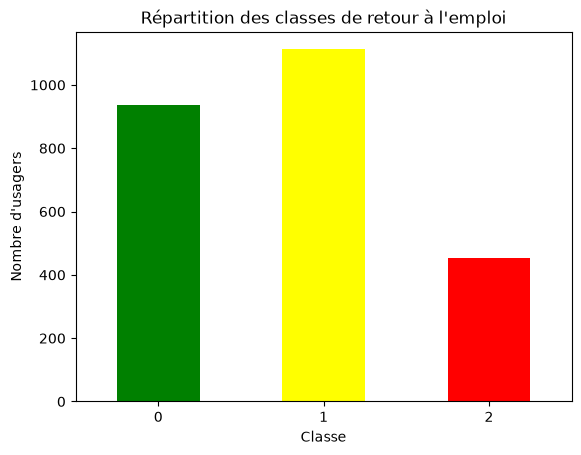

In [8]:
import matplotlib.pyplot as plt

df["classe_retour_emploi"].value_counts().sort_index().plot(
    kind="bar",
    color=["green", "yellow", "red"]
)

plt.title("Répartition des classes de retour à l'emploi")
plt.xlabel("Classe")
plt.ylabel("Nombre d'usagers")
plt.xticks(rotation=0)
plt.show()

## 2.5 Variables numériques

In [9]:
df[["age", "anciennete_poste_ans"]].describe()

,age,anciennete_poste_ans
count,2378.000000,2500.000000
mean,40.566442,2.971600
std,13.225242,2.979548
min,18.000000,0.000000
25%,29.000000,0.800000
50%,41.000000,2.000000
75%,52.000000,4.100000
max,63.000000,22.600000


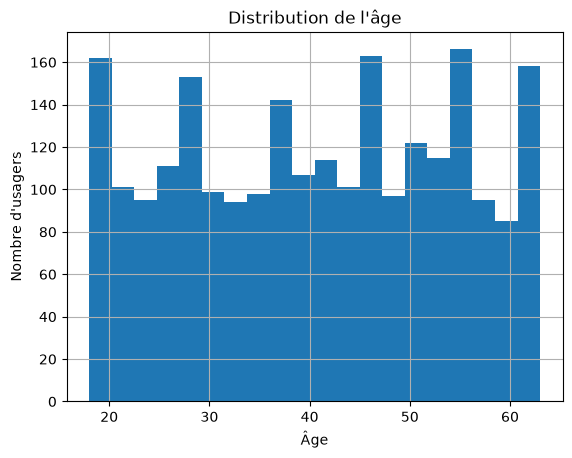

In [10]:
df["age"].hist(bins=20)
plt.title("Distribution de l'âge")
plt.xlabel("Âge")
plt.ylabel("Nombre d'usagers")
plt.show()

## 2.6 Variables catégorielles

In [11]:
colonnes_categorielles = [
    "niveau_diplome",
    "est_allocataire",
    "nationalite_hors_ue",
    "code_rome_vise"
]

for colonne in colonnes_categorielles:
    print("\n", colonne)
    print(df[colonne].value_counts(dropna=False))


 niveau_diplome
niveau_diplome
Bac             966
Bac+2           501
Sans diplôme    478
Bac+5           471
NaN              84
Name: count, dtype: int64

 est_allocataire
est_allocataire
1.0    1463
0.0     993
NaN      44
Name: count, dtype: int64

 nationalite_hors_ue
nationalite_hors_ue
0    2205
1     295
Name: count, dtype: int64

 code_rome_vise
code_rome_vise
H1206    71
G1801    64
G1601    63
D1210    63
K1403    62
I1304    62
M1602    61
H2502    60
A1203    59
K1304    58
N4301    56
M1203    56
M1806    55
M1805    54
C1302    53
A1401    53
C1110    53
N1301    52
N1303    52
M1802    52
C1201    51
D1503    50
K2111    50
A1301    50
H1504    49
J1301    48
J1506    48
K1201    48
D1406    48
M1801    48
N4101    48
K2106    47
G1302    46
G1602    46
A1501    45
C1501    45
M1501    45
D1401    45
K1903    45
A1202    44
M1705    43
N1101    43
D1502    42
K1601    42
M1607    41
K2101    40
G1203    38
F1603    38
C1102    38
W1401    30
Name: count, dtype: int64[

## 2.7 Texte

In [12]:
print("Nombre de textes différents :",
      df["synthese_entretien"].nunique())

df["synthese_entretien"].value_counts(dropna=False).head(15)

Nombre de textes différents : 9


synthese_entretien
Compétences à réactualiser sur les outils numériques. Motivation correcte.       338
Problème ponctuel de mobilité géographique. Zone mal desservie.                  334
Profil autonome, recherche active, aucun frein périphérique identifié.           300
Projet de reconversion à affiner. Besoin d'une formation complémentaire.         275
Excellente présentation, compétences techniques à jour. Reprise rapide visée.    272
Candidat très dynamique, mobilité nationale validée. Projet clair.               259
Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.     227
Perte de confiance importante. Risque d'exclusion, barrière de la langue.        212
Freins périphériques majeurs. Situation d'illettrisme numérique constatée.       202
NaN                                                                               81
Name: count, dtype: int64

## 2.8 Relations avec la cible

### 2.8.1 Relation bivariée Age vs. Cible

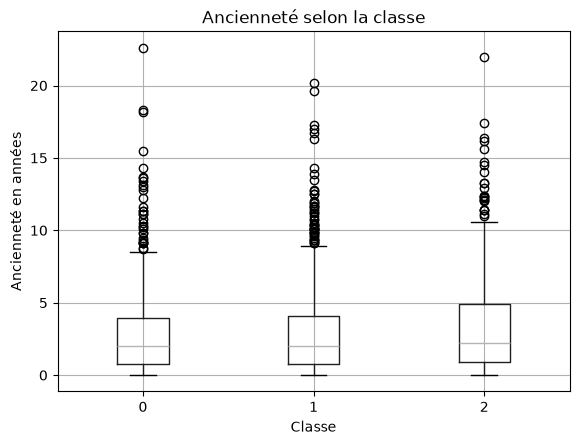

In [13]:
df.boxplot(
    column="anciennete_poste_ans",
    by="classe_retour_emploi"
)

plt.title("Ancienneté selon la classe")
plt.suptitle("")
plt.xlabel("Classe")
plt.ylabel("Ancienneté en années")
plt.show()

<Axes: xlabel='classe_retour_emploi', ylabel='age'>

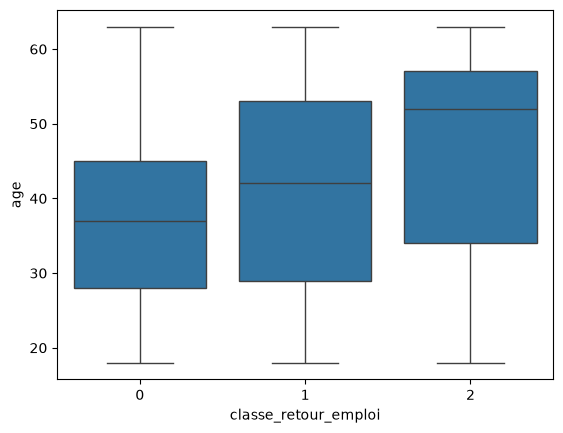

In [14]:
import seaborn as sns

sns.boxplot(
    data=df,
    x="classe_retour_emploi",
    y="age"
)

### 2.8.2 Relation bivariée Niveau de Diplôme vs. Cible

In [15]:
pd.crosstab(
    df["niveau_diplome"],
    df["classe_retour_emploi"],
    normalize="index"
).round(3)

classe_retour_emploi,0,1,2
niveau_diplome,,,
Bac,0.377,0.481,0.142
Bac+2,0.377,0.495,0.128
Bac+5,0.635,0.293,0.072
Sans diplôme,0.119,0.467,0.414


### 2.8.3 Relation bivariée Nationalité hors UE vs. Cible

In [16]:
pd.crosstab(
    df["nationalite_hors_ue"],
    df["classe_retour_emploi"],
    normalize="index"
).round(3)

classe_retour_emploi,0,1,2
nationalite_hors_ue,,,
0,0.406,0.440,0.154
1,0.139,0.481,0.380


### 2.8.4 Relation bivariée Allocataire vs. Cible

In [17]:
pd.crosstab(
    df["est_allocataire"],
    df["classe_retour_emploi"],
    normalize="index"
).round(3)

classe_retour_emploi,0,1,2
est_allocataire,,,
0.0,0.379,0.435,0.186
1.0,0.371,0.452,0.177


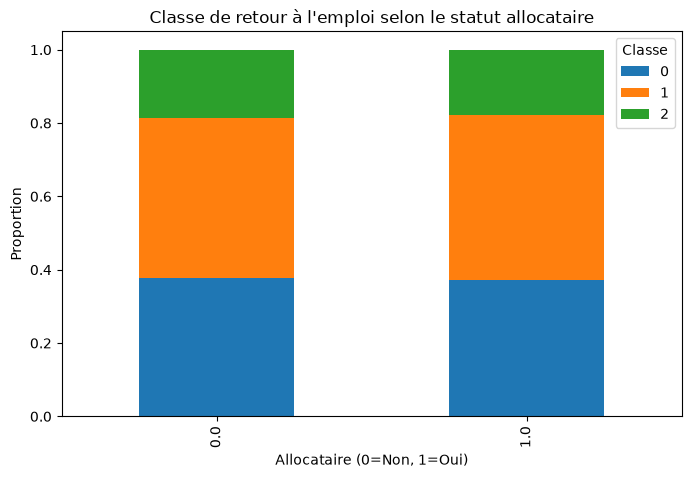

In [18]:
pd.crosstab(
    df["est_allocataire"],
    df["classe_retour_emploi"],
    normalize="index"
).plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Classe de retour à l'emploi selon le statut allocataire")
plt.xlabel("Allocataire (0=Non, 1=Oui)")
plt.ylabel("Proportion")
plt.legend(title="Classe")
plt.show()

### 2.8.5 Relation bivariée Ancienneté vs. Cible

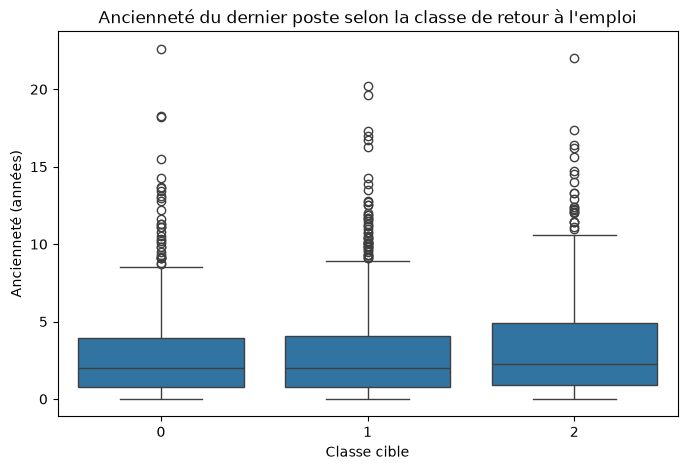

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="classe_retour_emploi",
    y="anciennete_poste_ans"
)

plt.title("Ancienneté du dernier poste selon la classe de retour à l'emploi")
plt.xlabel("Classe cible")
plt.ylabel("Ancienneté (années)")
plt.show()

In [20]:
df.groupby("classe_retour_emploi")["anciennete_poste_ans"].describe()

,count,mean,std,min,25%,50%,75%,max
classe_retour_emploi,,,,,,,,
0,936.0,2.782799,2.714854,0.0,0.8,2.00,3.925,22.6
1,1112.0,2.875899,2.844496,0.0,0.8,2.00,4.100,20.2
2,452.0,3.598009,3.672831,0.0,0.9,2.25,4.900,22.0


### Approche graphique systématique (Bonus)

In [21]:
def analyser_variable_categorielle(df, variable):
    
    tableau = pd.crosstab(
        df[variable],
        df["classe_retour_emploi"],
        normalize="index"
    ).round(3)

    print(tableau)

    tableau.plot(
        kind="bar",
        stacked=True,
        figsize=(8,5)
    )

    plt.title(f"{variable} vs classe_retour_emploi")
    plt.ylabel("Proportion")
    plt.show()

classe_retour_emploi      0      1      2
age                                      
18.0                  0.440  0.420  0.140
19.0                  0.333  0.517  0.150
20.0                  0.423  0.423  0.154
21.0                  0.245  0.633  0.122
22.0                  0.346  0.442  0.212
23.0                  0.412  0.471  0.118
24.0                  0.364  0.500  0.136
25.0                  0.524  0.381  0.095
26.0                  0.604  0.292  0.104
27.0                  0.447  0.404  0.149
28.0                  0.449  0.429  0.122
29.0                  0.404  0.404  0.193
30.0                  0.510  0.388  0.102
31.0                  0.580  0.300  0.120
32.0                  0.481  0.423  0.096
33.0                  0.452  0.524  0.024
34.0                  0.569  0.333  0.098
35.0                  0.489  0.404  0.106
36.0                  0.545  0.409  0.045
37.0                  0.600  0.320  0.080
38.0                  0.542  0.375  0.083
39.0                  0.481  0.442

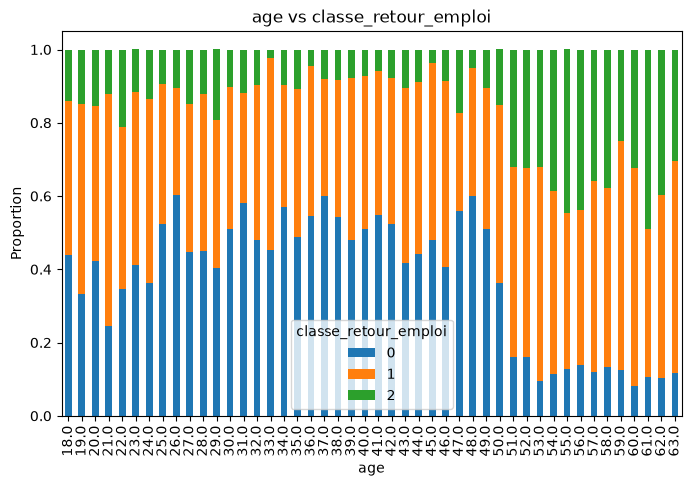

classe_retour_emploi      0      1      2
niveau_diplome                           
Bac                   0.377  0.481  0.142
Bac+2                 0.377  0.495  0.128
Bac+5                 0.635  0.293  0.072
Sans diplôme          0.119  0.467  0.414


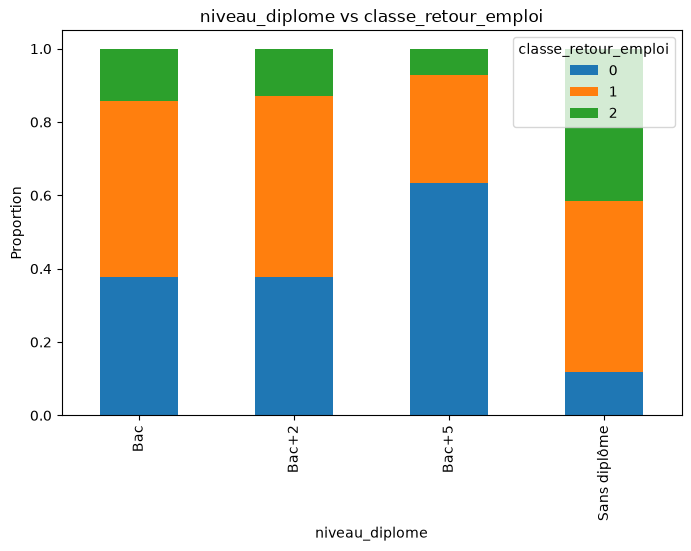

classe_retour_emploi      0      1      2
nationalite_hors_ue                      
0                     0.406  0.440  0.154
1                     0.139  0.481  0.380


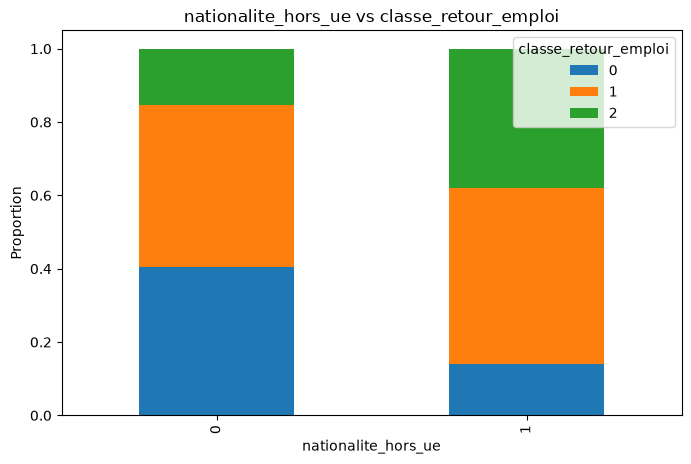

classe_retour_emploi      0      1      2
est_allocataire                          
0.0                   0.379  0.435  0.186
1.0                   0.371  0.452  0.177


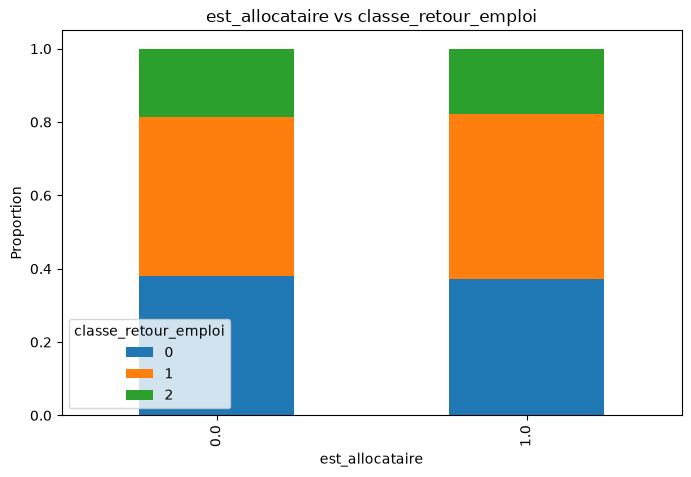

classe_retour_emploi      0      1      2
anciennete_poste_ans                     
0.0                   0.303  0.515  0.182
0.1                   0.379  0.455  0.167
0.2                   0.427  0.396  0.177
0.3                   0.415  0.402  0.183
0.4                   0.299  0.494  0.208
...                     ...    ...    ...
18.3                  1.000  0.000  0.000
19.6                  0.000  1.000  0.000
20.2                  0.000  1.000  0.000
22.0                  0.000  0.000  1.000
22.6                  1.000  0.000  0.000

[154 rows x 3 columns]


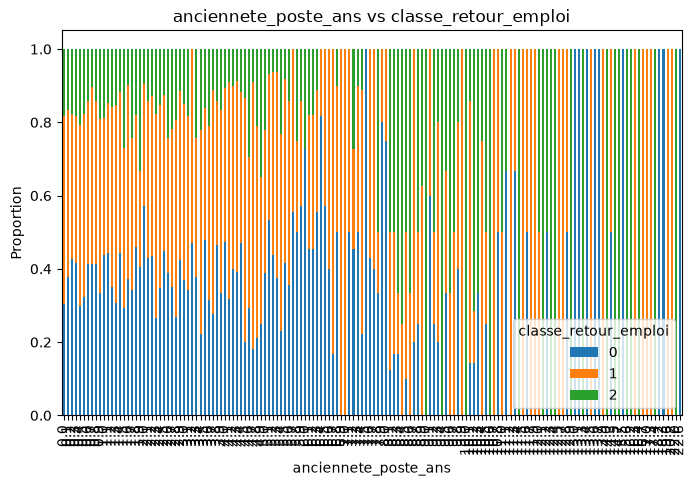

In [22]:
analyser_variable_categorielle(df, "age")

analyser_variable_categorielle(df, "niveau_diplome")

analyser_variable_categorielle(df, "nationalite_hors_ue")

analyser_variable_categorielle(df, "est_allocataire")

analyser_variable_categorielle(df, "anciennete_poste_ans")


### HEATMAP (Facultatif)

<Axes: >

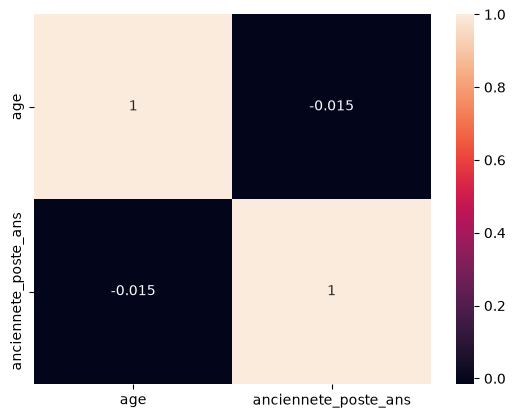

In [23]:
corr = df[
    ["age",
     "anciennete_poste_ans"]
].corr()

sns.heatmap(corr, annot=True)

## CONCLUSION
Une analyse univariée a été menée afin de caractériser les distributions des variables et d'identifier les valeurs manquantes. Une analyse bivariée entre chaque variable explicative et la cible a ensuite été réalisée afin d'identifier les facteurs potentiellement associés au délai de retour à l'emploi. Cette étape met notamment en évidence une relation entre le niveau de diplôme et le risque de chômage de longue durée, ainsi qu'une association statistique entre certaines variables contextuelles et la classe cible. Ces observations motivent l'utilisation de modèles supervisés capables de capturer ces relations et seront confrontées aux résultats obtenus lors de l'entraînement des modèles.

# -----------------------------------------------------------------------------------

# 3. Nettoyage et Feature Engineering

## 3.1 Contrôle de qualité des données

### 3.1.1 Valeurs manquantes

In [24]:
df.isna().sum()

usager_id                 0
age                     122
niveau_diplome           84
anciennete_poste_ans      0
code_rome_vise            0
code_insee_commune        0
est_allocataire          44
nationalite_hors_ue       0
synthese_entretien       81
classe_retour_emploi      0
dtype: int64

### 3.1.2 Doublons

In [25]:
print("Doublons :", df.duplicated().sum())
print("Usager_id dupliqués :", df["usager_id"].duplicated().sum())

Doublons : 0
Usager_id dupliqués : 0


On observe aucun doublon complet ni aucun usager dupliqué.

## 3.2 Création des nouvelles variables

### 3.2.1 Département à partir du code INSEE
Extraction du code Département à partir des 2 premiers caractères du code INSEE et création d'une variable dédiée pour pouvoir regrouper les données par département.

### 3.2.2 Famille ROME (Répertoire Opérationnel des Métiers et des Emplois)
Extraction du code Famille ROME à partir du premier caractère du code ROME visé et création d'une variable dédiée pour pouvoir regrouper les données par famille de mérier.

In [26]:
from src.features import creer_features

df = creer_features(df)

df.head()

,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi,departement,famille_rome
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1,18,D
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2,07,G
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0,01,M
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1,63,A
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0,21,N


## 3.3 Traitement des valeurs manquantes

Propositions de règles d'imputation pour renseigner les valeurs manquantes pour les 4 variables identifiées précédemment:
- Imputation de la médiane pour les variables numériques ('age')
- Imputation "Non Renseigné" pour la variable 'niveau_diplome'
- Imputation de la valeur la plus fréquente pour la variable 'est_allocataire'
- Imputation d'une chaîne (string) vide pour la variable 'synthese_entretien'

## 3.4 Construction des listes de variables

Définition de listes de variables pour plus de facilité de manipulation (cf. fichier source preprocessing.py).

In [27]:
from src.preprocessing import (
    VARIABLES_NUMERIQUES,
    VARIABLES_CATEGORIELLES,
    VARIABLE_TEXTE,
    CIBLE
)

In [28]:
print(VARIABLES_NUMERIQUES)
print(VARIABLES_CATEGORIELLES)
print(VARIABLE_TEXTE)
print(CIBLE)

['age', 'anciennete_poste_ans']
['niveau_diplome', 'famille_rome', 'departement', 'est_allocataire', 'nationalite_hors_ue']
synthese_entretien
classe_retour_emploi


## CONCLUSION
Les contrôles de qualité n'ont révélé aucun doublon. Plusieurs variables présentent cependant des valeurs manquantes qui seront traitées dans le pipeline de prétraitement. Deux nouvelles variables ont été créées : le département extrait du code INSEE et la famille métier dérivée du code ROME. Ces transformations visent à réduire la cardinalité des données tout en préservant l'information métier utile à la prédiction.

# -----------------------------------------------------------------------------------

# 4. Construction du pipeline de prétraitement

## 4.1 Objectif

Afin d'éviter les fuites de données et de garantir la reproductibilité des résultats, l'ensemble des transformations est regroupé au sein d'un pipeline de prétraitement Scikit-Learn. Ce pipeline sera réutilisé lors de l'entraînement, du déploiement FastAPI et des phases de réentraînement.

## 4.2 Séparation Train/Test

In [29]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["classe_retour_emploi"])
y = df["classe_retour_emploi"]

# Split des jeux de train et de test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (2000, 11)
Test  : (500, 11)


J'ai réalisé un découpage stratifié afin de conserver la même distribution de la variable cible dans les jeux d'entraînement et de test. Cela permet d'obtenir une évaluation plus représentative des performances du modèle. Voir répartitions des différents jeu ci-dessous:

In [30]:
print("Répartition globale")
print(y.value_counts(normalize=True))

print("\nRépartition train")
print(y_train.value_counts(normalize=True))

print("\nRépartition test")
print(y_test.value_counts(normalize=True))

Répartition globale
classe_retour_emploi
1    0.4448
0    0.3744
2    0.1808
Name: proportion, dtype: float64

Répartition train
classe_retour_emploi
1    0.4445
0    0.3745
2    0.1810
Name: proportion, dtype: float64

Répartition test
classe_retour_emploi
1    0.446
0    0.374
2    0.180
Name: proportion, dtype: float64


In [31]:
# Preprocesseur
from src.preprocessing import (
    construire_preprocesseur
)

preprocesseur = construire_preprocesseur()

preprocesseur

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [32]:
# Transformation train
X_train_transforme = preprocesseur.fit_transform(
    X_train,
    y_train
)

print("Train initial :", X_train.shape)
print("Train après transformation :", X_train_transforme.shape)

Train initial : (2000, 11)
Train après transformation : (2000, 254)


In [33]:
# Transformation test
X_test_transforme = preprocesseur.transform(
    X_test
)

In [34]:
feature_names = preprocesseur.get_feature_names_out()

print("Nombre de variables :", len(feature_names))
print(feature_names[:20])

Nombre de variables : 254
['num__age' 'num__anciennete_poste_ans' 'cat__niveau_diplome_Bac'
 'cat__niveau_diplome_Bac+2' 'cat__niveau_diplome_Bac+5'
 'cat__niveau_diplome_Sans diplôme' 'cat__famille_rome_A'
 'cat__famille_rome_C' 'cat__famille_rome_D' 'cat__famille_rome_F'
 'cat__famille_rome_G' 'cat__famille_rome_H' 'cat__famille_rome_I'
 'cat__famille_rome_J' 'cat__famille_rome_K' 'cat__famille_rome_M'
 'cat__famille_rome_N' 'cat__famille_rome_W' 'cat__departement_01'
 'cat__departement_02']


On voit que de nombreuses colonnes ont été créées : le prétraitement a enrichi l'espace de caractéristiques. Les variables catégorielles ont été encodées via One-Hot Encoding  et la variable textuelle a été vectorisée par TF-IDF, ce qui a porté le nombre de variables de 11 à 254.

In [35]:
print(df.columns.tolist())


['usager_id', 'age', 'niveau_diplome', 'anciennete_poste_ans', 'code_rome_vise', 'code_insee_commune', 'est_allocataire', 'nationalite_hors_ue', 'synthese_entretien', 'classe_retour_emploi', 'departement', 'famille_rome']


In [36]:
from src.preprocessing import VARIABLES_CATEGORIELLES

for colonne in VARIABLES_CATEGORIELLES:
    print(
        colonne,
        "→ type :",
        X_train[colonne].dtype,
        "→ valeurs :",
        X_train[colonne].dropna().unique()[:5]
    )

niveau_diplome → type : str → valeurs : <ArrowStringArray>
['Bac', 'Bac+2', 'Sans diplôme', 'Bac+5']
Length: 4, dtype: str
famille_rome → type : string → valeurs : <ArrowStringArray>
['C', 'A', 'N', 'K', 'M']
Length: 5, dtype: string
departement → type : str → valeurs : <ArrowStringArray>
['68', '24', '91', '23', '19']
Length: 5, dtype: str
est_allocataire → type : float64 → valeurs : [1. 0.]
nationalite_hors_ue → type : int64 → valeurs : [0 1]


## CONCLUSION
Les données sont désormais préparées afin qu'elles soient exploitables par les algorithmes de machine learning.

Transformations réalisées :
- Imputation médiane des variables numériques.
- Standardisation des variables numériques.
- Imputation par la modalité la plus fréquente pour les variables catégorielles.
- Encodage One-Hot des variables catégorielles.
- Vectorisation TF-IDF de la variable textuelle synthese_entretien.
- Conservation d'un pipeline unique via ColumnTransformer.

Résultat :
Le jeu de données est passé de 11 variables brutes à 254 variables exploitables après prétraitement.

# -----------------------------------------------------------------------------------

# 5. Modélisation

## 5.1 Objectif

Nous allons comparer 3 modèles différents :
- Modèle 1 : Régression Logistique (modèle simple qui nous servira de référence)
- Modèle 2 : Random Forest (modèle à base d’arbres capable de modéliser des relations non linéaires)
- Modèle 3 : Linear SVC (modèle souvent adapté aux données textuelles vectorisées par TF-IDF)

Ces 3 modèles sont compatibles avec le format produit par TF-IDF et One-Hot (contrairement au GradientBoosting initialement visé).

Pour chacun de ces modèles, nous allons calculer et comparer les métriques suivantes:
- l'accuracy (accuracy_score)
- la précision (precision_score)
- le rappel (recall_score)
- le score f1 (f1_score)
- le rapport de classification (classification_report)
- la matrice de confusion (confusion_matrix)

En effet il est important de ne pas se fier uniquement à un seul indicateur car celui-ci peut être tromperu selon le cas de figure et le besoin métier recherché. Exemple : l'accuracy peut être trompeuse lorsque les classes sont déséquilibrées ce qui est le cas ici. Le f1_score combine la précision et le rappel et est plus robuste dans ce cas.

## 5.2 Construction et run des 3 modèles

In [37]:
from src.modeles import construire_modeles

In [38]:
# Création des modèles
modeles = construire_modeles()

In [39]:
# Boucle d'entraînement
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Réinitialisation de la liste
resultats = []

# Entraînement et évaluation des trois modèles
for nom, modele in modeles.items():

    modele.fit(
        X_train_transforme,
        y_train
    )

    y_pred = modele.predict(
        X_test_transforme
    )

    resultats.append({
        "modele": nom,
        "accuracy": round(
            accuracy_score(y_test, y_pred),
            3
        ),
        "precision_weighted": round(
            precision_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            ),
            3
        ),
        "recall_weighted": round(
            recall_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            ),
            3
        ),
        "f1_weighted": round(
            f1_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            ),
            3
        ),
        "f1_macro": round(
            f1_score(
                y_test,
                y_pred,
                average="macro",
                zero_division=0
            ),
            3
        )
    })


- On utilise average="weighted" car la cible présente 3 valuers possibles et il s'agit donc d'un problème multiclasse.
- On ajoute zero_division=0 car si un modèle ne prédit aucune observation pour l’une des trois classes, certaines métriques peuvent alors être impossibles à calculer. Ce paramètre évite un avertissement et affecte alors la valeur 0 à la métrique concernée.

In [40]:
# Création et affichage du tableau comparatif
df_resultats = pd.DataFrame(resultats)

df_resultats = df_resultats.sort_values(
    by="f1_macro",
    ascending=False
).reset_index(drop=True)

df_resultats

,modele,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro
0,Linear SVC,0.702,0.699,0.702,0.700,0.676
1,Regression logistique,0.690,0.686,0.690,0.687,0.657
2,Random Forest,0.676,0.672,0.676,0.670,0.638


On reagrder principalement l'indicateur f1_macro car celui-ci donne le même poids aux 3 classes (ce qui n'est pas le cas de f1_macro qui favorise les grosses classes).

In [41]:
print(
    f"Meilleur modèle : {df_resultats.loc[0, 'modele']}"
)

Meilleur modèle : Linear SVC


Parmi les trois modèles testés, Linear SVC obtient les meilleures performances globales, avec une accuracy de 0,702 et un F1-score macro  de 0,676. Il est donc retenu provisoirement comme meilleur modèle. Les performances détaillées par classe et la matrice de confusion doivent toutefois être examinées avant de confirmer ce choix, notamment pour la classe 2, moins représentée.

Meilleur modèle : Linear SVC

Rapport de classification :
              precision    recall  f1-score   support

           0       0.72      0.78      0.75       187
           1       0.72      0.71      0.71       223
           2       0.61      0.53      0.57        90

    accuracy                           0.70       500
   macro avg       0.68      0.67      0.68       500
weighted avg       0.70      0.70      0.70       500



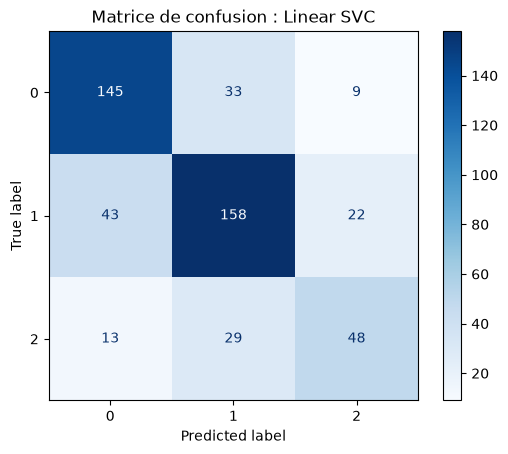

In [42]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


# Nom du meilleur modèle
nom_meilleur_modele = df_resultats.loc[0, "modele"]

# Récupération du modèle correspondant
meilleur_modele = modeles[nom_meilleur_modele]

# Prédictions sur le jeu de test
y_pred_meilleur = meilleur_modele.predict(
    X_test_transforme
)

print("Meilleur modèle :", nom_meilleur_modele)

print("\nRapport de classification :")
print(
    classification_report(
        y_test,
        y_pred_meilleur,
        zero_division=0
    )
)

# Matrice de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_meilleur,
    cmap="Blues"
)

plt.title(
    f"Matrice de confusion : {nom_meilleur_modele}"
)

plt.show()

L'analyse détaillée du rapport de classification montre que les classes majoritaires sont correctement prédites. La classe minoritaire est plus difficile à distinguer, ce qui est cohérent avec sa plus faible représentation dans le jeu de données. Le modèle reste néanmoins suffisamment équilibré pour être retenu pour la suite du projet.
La "diagonale" de la matrice de confusion est solide par rapport aux erreurs hors diagonale.

## CONCLUSION
Le modèle Linear SVC est le modèle qui obtient les meilleures performances parmi les trois modèles évalués. Il atteint une accuracy de 70 %, un F1-score pondéré de 0,70 et un F1-score macro de 0,68 sur le jeu de test.
Il est également particulièrement adapté aux données textuelles vectorisées par TF-IDF.

Les classes 0 et 1 sont correctement prédites avec des F1-scores respectifs de 0,75 et 0,71. La classe 2 est plus difficile à identifier (F1-score de 0,57), ce qui peut s'expliquer par sa plus faible représentation dans le jeu de données. Malgré cette difficulté, les performances restent homogènes entre les différentes classes et justifient la sélection de Linear SVC comme modèle final.


## 5.3 Optimisation du modèle retenu

L'hyperparamètre principal de LinearSVC est C :
- par défaut C= 1.0
- une petite valeur de C correspond à une régularisation forte
- une grande valeur de C correspond à une modèle plus complexe.


Afin de tester l'impact de l'hyperparamètre C, on réalise le test pour 3 valeurs C= 0.1, C= 1.0, C= 10.0

In [43]:
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score

resultats_svc = []

for c in [0.1, 1, 10]:

    modele = LinearSVC(
        C=c,
        random_state=42
    )

    modele.fit(
        X_train_transforme,
        y_train
    )

    y_pred = modele.predict(
        X_test_transforme
    )

    resultats_svc.append({
        "C": c,
        "f1_macro": round(
            f1_score(
                y_test,
                y_pred,
                average="macro"
            ),
            3
        ),
        "f1_weighted": round(
            f1_score(
                y_test,
                y_pred,
                average="weighted"
            ),
            3
        )
    })

pd.DataFrame(resultats_svc)

,C,f1_macro,f1_weighted
0,0.1,0.678,0.702
1,1.0,0.676,0.700
2,10.0,0.675,0.700


Les performances obtenues sont très proches. Le modèle est donc relativement stable vis-à-vis de ce paramètre. Une optimisation plus poussée n'apporte pas de gain significatif.

On observe quand même une légère amélioration pour C =0.1. On conserve donc cette valeur dans le paramètrage du modèle (cf. fichier modeles.py).

# -----------------------------------------------------------------------------------

# 6. Interprétation du modèle et analyse des variables importantes

## 6.1 Objectif

L'objectif est de répondre à la question suivante :
quels sont les facteurs qui influencent le plus les prédictions du modèle ?

In [44]:
print(type(meilleur_modele))
print(meilleur_modele.coef_.shape)

feature_names = preprocesseur.get_feature_names_out()
print(len(feature_names))

<class 'sklearn.svm._classes.LinearSVC'>
(3, 254)
254


## 6.2 Analyse des 3 classes

### 6.2.1 Classe 0

In [45]:
import pandas as pd

importance_0 = pd.DataFrame({
    "variable": feature_names,
    "coefficient": meilleur_modele.coef_[0]
})

importance_0.sort_values(
    by="coefficient",
    ascending=False
).head(20)

,variable,coefficient
13,cat__famille_rome_J,0.673035
32,cat__departement_15,0.594615
48,cat__departement_30,0.550321
100,cat__departement_83,0.511494
4,cat__niveau_diplome_Bac+5,0.502638
96,cat__departement_79,0.426419
81,cat__departement_63,0.410545
26,cat__departement_09,0.368919
68,cat__departement_50,0.355084
76,cat__departement_58,0.354379


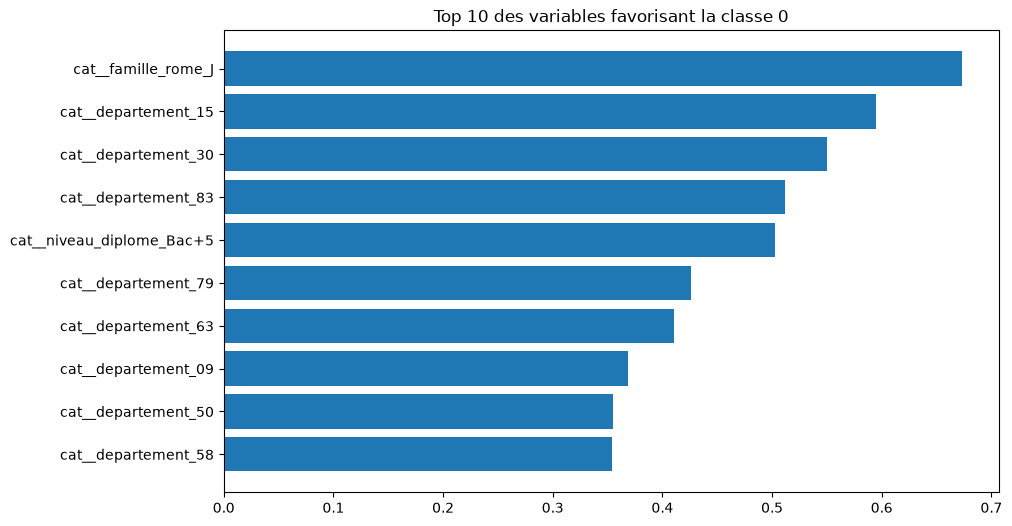

In [46]:
import matplotlib.pyplot as plt

top10 = (
    importance_0
    .sort_values(
        by="coefficient",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["variable"],
    top10["coefficient"]
)

plt.title(
    "Top 10 des variables favorisant la classe 0"
)

plt.gca().invert_yaxis()

plt.show()

### 6.2.1 Classe 1

In [47]:
importance_1 = pd.DataFrame({
    "variable": feature_names,
    "coefficient": meilleur_modele.coef_[1]
})

importance_1.sort_values(
    by="coefficient",
    ascending=False
).head(20)

,variable,coefficient
54,cat__departement_36,0.531673
40,cat__departement_24,0.453886
58,cat__departement_40,0.419115
111,cat__departement_94,0.418645
90,cat__departement_72,0.348246
57,cat__departement_39,0.348168
83,cat__departement_65,0.345935
60,cat__departement_42,0.339459
6,cat__famille_rome_A,0.286150
70,cat__departement_52,0.279293


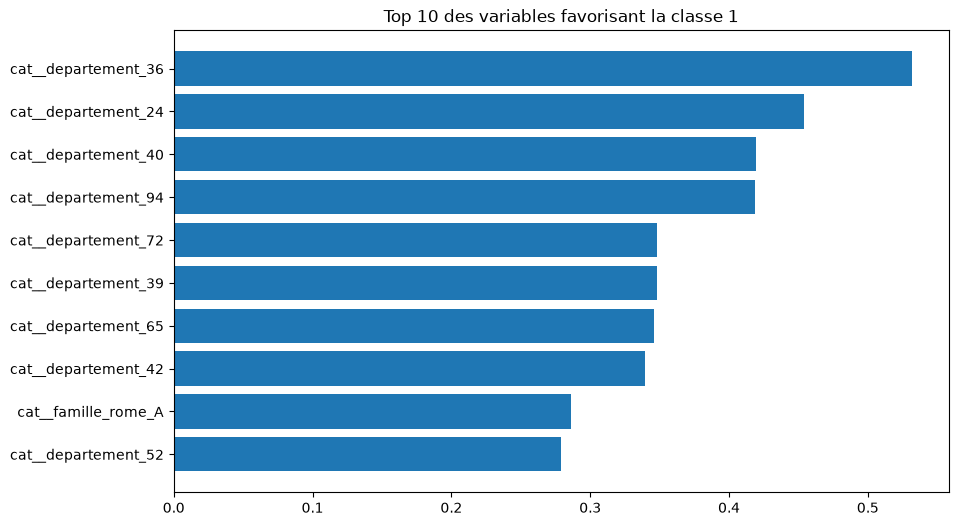

In [48]:
import matplotlib.pyplot as plt

top10 = (
    importance_1
    .sort_values(
        by="coefficient",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["variable"],
    top10["coefficient"]
)

plt.title(
    "Top 10 des variables favorisant la classe 1"
)

plt.gca().invert_yaxis()

plt.show()

### 6.2.1 Classe 2

In [49]:
importance_2 = pd.DataFrame({
    "variable": feature_names,
    "coefficient": meilleur_modele.coef_[2]
})

importance_2.sort_values(
    by="coefficient",
    ascending=False
).head(20)

,variable,coefficient
109,cat__departement_92,1.157551
84,cat__departement_66,0.976248
110,cat__departement_93,0.824437
30,cat__departement_13,0.716272
22,cat__departement_05,0.557358
55,cat__departement_37,0.498290
5,cat__niveau_diplome_Sans diplôme,0.463133
92,cat__departement_74,0.429730
113,cat__departement_97,0.373102
34,cat__departement_17,0.352474


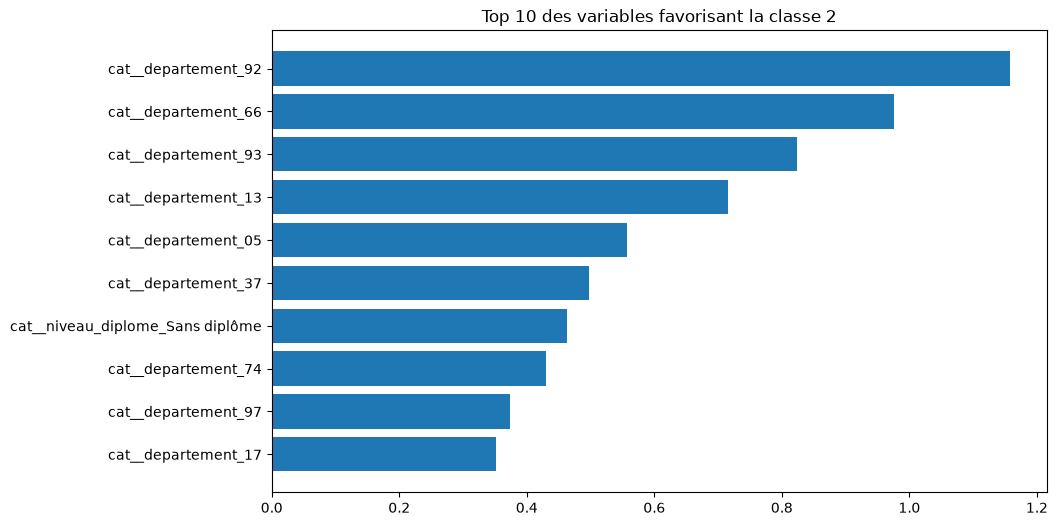

In [50]:
import matplotlib.pyplot as plt

top10 = (
    importance_2
    .sort_values(
        by="coefficient",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["variable"],
    top10["coefficient"]
)

plt.title(
    "Top 10 des variables favorisant la classe 2"
)

plt.gca().invert_yaxis()

plt.show()

## CONCLUSION
L'interprétation des coefficients du modèle Linear SVC montre que les variables les plus influentes sont principalement liées au département de résidence, à la famille professionnelle ROME visée et au niveau de diplôme du candidat.

Ces caractéristiques apparaissent comme les principaux facteurs discriminants utilisés par le modèle pour prédire la classe cible.

Les variables textuelles issues des synthèses d'entretien apportent une information complémentaire mais semblent moins déterminantes que les variables structurées dans la version actuelle du modèle.

Une attention particulière doit néanmoins être portée aux variables géographiques afin de s'assurer que le modèle ne reproduit pas des disparités territoriales présentes dans les données historiques.

# -----------------------------------------------------------------------------------

# 7. Validation croisée stratifiée

## 7.1 Objectif

La validation croisée stratifiée va :
- découper plusieurs fois le jeu d’entraînement ;
- conserver la proportion des classes dans chaque découpage ;
- entraîner et évaluer chaque modèle plusieurs fois ;
- calculer une moyenne et un écart-type.

Pour éviter une fuite d’information entre les plis, nous allons placer dans un même pipeline : Préprocessing → Modèle. 
Ainsi, le préprocesseur sera réentraîné indépendamment dans chaque pli.

## 7.2 Configuration de la validation croisée

In [51]:
import pandas as pd

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.pipeline import Pipeline

from src.preprocessing import construire_preprocesseur
from src.modeles import construire_modeles

In [52]:
validation_croisee = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Signification :
- n_splits=5 : cinq entraînements et cinq validations ;
- shuffle=True : mélange des observations avant découpage ;
- random_state=42 : résultats reproductibles ;
- StratifiedKFold : conservation de la proportion des classes.

## 7.3 Comparaison des trois modèles par validation croisée

In [53]:
# Réinitialisation des résultats
resultats_cv = []

# Création des modèles
modeles = construire_modeles()

# Validation croisée stratifiée
validation_croisee = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Métriques utilisées
metriques = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted"
}

# Comparaison des modèles
for nom, modele in modeles.items():

    # Nouveau préprocesseur pour chaque modèle
    preprocesseur_cv = construire_preprocesseur()

    # Pipeline complet :
    # préprocessing puis modèle
    pipeline_complet = Pipeline(
        steps=[
            ("preprocessing", preprocesseur_cv),
            ("modele", modele)
        ]
    )

    # Validation croisée uniquement sur le train
    scores = cross_validate(
        pipeline_complet,
        X_train,
        y_train,
        cv=validation_croisee,
        scoring=metriques
    )

    # Enregistrement des moyennes et écarts-types
    resultats_cv.append({
        "modele": nom,

        "accuracy_moyenne": round(
            scores["test_accuracy"].mean(),
            3
        ),

        "accuracy_ecart_type": round(
            scores["test_accuracy"].std(),
            3
        ),

        "f1_macro_moyen": round(
            scores["test_f1_macro"].mean(),
            3
        ),

        "f1_macro_ecart_type": round(
            scores["test_f1_macro"].std(),
            3
        ),

        "f1_weighted_moyen": round(
            scores["test_f1_weighted"].mean(),
            3
        )
    })

# Tableau comparatif
df_resultats_cv = (
    pd.DataFrame(resultats_cv)
    .sort_values(
        by="f1_macro_moyen",
        ascending=False
    )
    .reset_index(drop=True)
)

df_resultats_cv

,modele,accuracy_moyenne,accuracy_ecart_type,f1_macro_moyen,f1_macro_ecart_type,f1_weighted_moyen
0,Regression logistique,0.698,0.020,0.673,0.013,0.696
1,Random Forest,0.692,0.015,0.665,0.012,0.690
2,Linear SVC,0.689,0.023,0.664,0.021,0.688


Les résultats de la validation croisée confirment ceux obtenus sur un unique jeu de test. Ici le modèle LinearSVC reste le modèle le plus performant, amsi de très peu, car la régression logistique présente des résultats presque aussi bon (f1_macro_moyen = 0.673 vs 0.676).

A noter que l'hyperparamétrage supplémentaire a aidé car le 1er run de test en gardant C=1 montrait un résulat inverse (quoique toujours très proche).

## CONCLUSION
Une validation croisée stratifiée à 5 plis a été réalisée afin d'évaluer la robustesse des modèles face aux variations des données d'entraînement. Les résultats confirment 2 modèles très prochees mais Linear SVC présente bien les meilleures performances moyennes en validation croisée (F1 Macro = 0,676).

Le modèle Linear SVC est donc bien le modèle le plus adapté d'un pointde vue statistique.

# -----------------------------------------------------------------------------------

# 8. Gestion du risque métier critique

## 8.1 Objectif

L'énoncé du problème est le suivant: « Une situation d'un niveau de risque 2 (chômage de longue durée) classée niveau 0 (retour rapide) est une erreur bien plus grave d'un point de vue humain et financier qu'une situation de niveau 0 classée niveau 1 ou 2, car elle prive l'usager d'un accompagnement renforcé indispensable. » 

Nous allons étudier l'impact du poids de la classe 2 qui est la classe la plus critique.

## 8.2 Approche et définition des 3 pondérations à comparer

Nous partons de la régression logistique sélectionnée après validation croisée.

Nous allons comparer trois versions simples :

1. aucune pondération ;
2. pondération automatique balanced ;
3. pondération métier renforcée pour la classe 2.

In [54]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    confusion_matrix,
    classification_report
)

from src.preprocessing import construire_preprocesseur

In [55]:
# Définition des 3 configurations retenues
configurations = {
    "Sans pondération": None,

    "Balanced": "balanced",

    "Poids métier classe 2 x2": {
        0: 1,
        1: 1,
        2: 2
    }
}

In [56]:
# Appel à la fonction pour compter les erreurs critiques
from src.evaluation import (
    compter_erreurs_critiques
)


## 8.3 Entraînement et comparaison des configurations - Modèle Linear SVC Retenu

In [57]:
# Réinitialisation des résultats
resultats_risque = []

# Conservation des modèles entraînés
modeles_risque = {}

for nom, poids in configurations.items():

    # Pipeline complet :
    # preprocessing puis régression logistique
    pipeline = Pipeline(
        steps=[
            (
                "preprocessing",
                construire_preprocesseur()
            ),
            (
                "modele",
                LinearSVC(
                    C=0.1,
                    class_weight=poids,
                    random_state=42
                )
            )
        ]
    )

    # Entraînement uniquement sur le jeu de train
    pipeline.fit(
        X_train,
        y_train
    )

    # Prédictions sur le jeu de test
    y_pred = pipeline.predict(
        X_test
    )

    # Sauvegarde du modèle et des prédictions
    modeles_risque[nom] = {
        "pipeline": pipeline,
        "predictions": y_pred
    }

    # Calcul des métriques
    resultats_risque.append({
        "configuration": nom,

        "accuracy": round(
            accuracy_score(y_test, y_pred),
            3
        ),

        "f1_macro": round(
            f1_score(
                y_test,
                y_pred,
                average="macro",
                zero_division=0
            ),
            3
        ),

        "f1_weighted": round(
            f1_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            ),
            3
        ),

        "recall_classe_2": round(
            recall_score(
                y_test,
                y_pred,
                labels=[2],
                average=None,
                zero_division=0
            )[0],
            3
        ),

        "erreurs_critiques_2_vers_0":
            compter_erreurs_critiques(
                y_test,
                y_pred
            )
    })
    

In [58]:
df_resultats_risque = (
    pd.DataFrame(resultats_risque)
    .sort_values(
        by=[
            "erreurs_critiques_2_vers_0",
            "f1_macro"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

df_resultats_risque

,configuration,accuracy,f1_macro,f1_weighted,recall_classe_2,erreurs_critiques_2_vers_0
0,Balanced,0.694,0.673,0.696,0.611,10
1,Poids métier classe 2 x2,0.694,0.673,0.696,0.611,10
2,Sans pondération,0.704,0.678,0.702,0.533,13


Le tableau contient maintenant deux familles d’indicateurs.

- Indicateurs globaux : accuracy + f1_macro + f1_weighted
Ils permettent de vérifier que l’amélioration de la classe 2 ne dégrade pas excessivement les performances générales.

- Indicateurs métier prioritaires : recall_classe_2 + erreurs_critiques_2_vers_0

Le rappel de la classe 2 répond à la question : parmi les usagers réellement à risque de retour à l’emploi supérieur à 12 mois, quelle proportion le modèle identifie-t-il correctement ?

Le nombre d’erreurs critiques répond directement à l’exigence métier : combien d’usagers réels de classe 2 ont été incorrectement classés en retour rapide, classe 0 ?



#### Matrice de confusion de chaque configuration

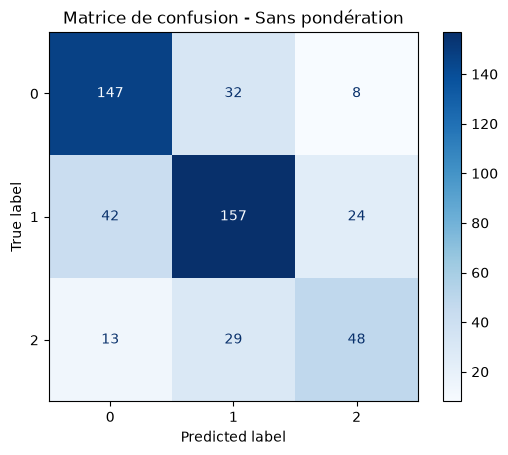

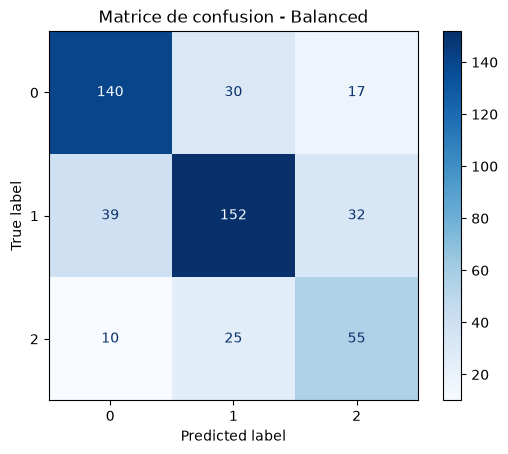

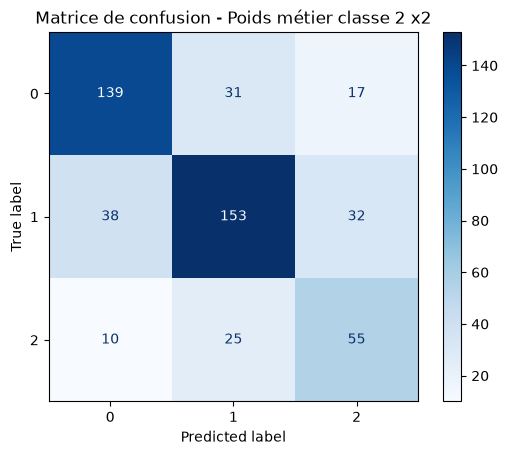

In [59]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay


for nom, contenu in modeles_risque.items():

    y_pred = contenu["predictions"]

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        labels=[0, 1, 2],
        cmap="Blues"
    )

    plt.title(
        f"Matrice de confusion - {nom}"
    )

    plt.show()

## 8.5 Analyse des résultats

- Le modèle sans pondération  présente une meilleure accuracy mais 13 erreurs critiques et  ne détecte correctement que 53,3 % des situations à risque de longue durée (Recall classe 2 = 0.533).
- Le modèle balanced augmente fortement la détection de la classe 2 (Recall classe 2 = 0.611) et réduit les erreurs critiques.
- Le modèle 'classe 2 x2' obtient des résulats similaire à la configuration balanced.

## 8.6 Modèle Régression Linéaire en tant que challenger

Si l'on réalise le même exercice avec le modèle Régression Linéaire, légèrement moins performant en terme statistique :

In [60]:
# Réinitialisation des résultats
resultats_risque = []

# Conservation des modèles entraînés
modeles_risque = {}

for nom, poids in configurations.items():

    # Pipeline complet :
    # preprocessing puis régression logistique
    pipeline = Pipeline(
        steps=[
            (
                "preprocessing",
                construire_preprocesseur()
            ),
            (
                "modele",
                LogisticRegression(
                    max_iter=1000,
                    class_weight=poids,
                    random_state=42
                )
            )
        ]
    )

    # Entraînement uniquement sur le jeu de train
    pipeline.fit(
        X_train,
        y_train
    )

    # Prédictions sur le jeu de test
    y_pred = pipeline.predict(
        X_test
    )

    # Sauvegarde du modèle et des prédictions
    modeles_risque[nom] = {
        "pipeline": pipeline,
        "predictions": y_pred
    }

    # Calcul des métriques
    resultats_risque.append({
        "configuration": nom,

        "accuracy": round(
            accuracy_score(y_test, y_pred),
            3
        ),

        "f1_macro": round(
            f1_score(
                y_test,
                y_pred,
                average="macro",
                zero_division=0
            ),
            3
        ),

        "f1_weighted": round(
            f1_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            ),
            3
        ),

        "recall_classe_2": round(
            recall_score(
                y_test,
                y_pred,
                labels=[2],
                average=None,
                zero_division=0
            )[0],
            3
        ),

        "erreurs_critiques_2_vers_0":
            compter_erreurs_critiques(
                y_test,
                y_pred
            )
    })
    

In [61]:
df_resultats_risque = (
    pd.DataFrame(resultats_risque)
    .sort_values(
        by=[
            "erreurs_critiques_2_vers_0",
            "f1_macro"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

df_resultats_risque

,configuration,accuracy,f1_macro,f1_weighted,recall_classe_2,erreurs_critiques_2_vers_0
0,Poids métier classe 2 x2,0.688,0.669,0.691,0.633,8
1,Balanced,0.678,0.660,0.681,0.644,8
2,Sans pondération,0.690,0.657,0.687,0.478,13


- On voit que la configuration où la classe 2 est pondérée permet avec modèle d'obtenir un rappel de 63,3% contre 61,1% avec le modèle Linear SVC.
- D'un point de vué performance métier ce modèle de Regression Linéaire est donc potentiellement plus adapté !

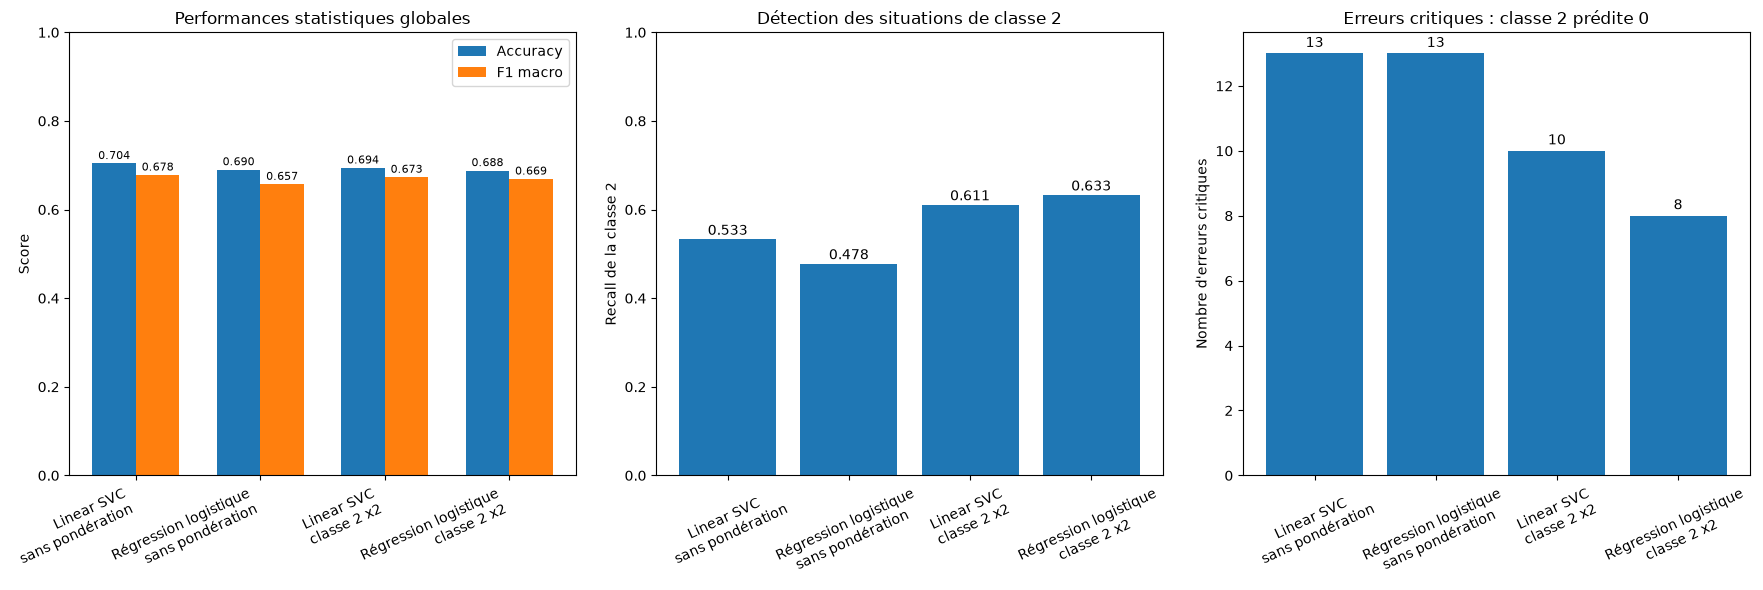

,configuration,modele,approche,accuracy,f1_macro,recall_classe_2,erreurs_critiques_2_vers_0
0,Linear SVC\nsans pondération,Linear SVC,Statistique,0.704,0.678,0.533,13
1,Régression logistique\nsans pondération,Régression logistique,Statistique,0.690,0.657,0.478,13
2,Linear SVC\nclasse 2 x2,Linear SVC,Métier,0.694,0.673,0.611,10
3,Régression logistique\nclasse 2 x2,Régression logistique,Métier,0.688,0.669,0.633,8


In [62]:
import pandas as pd
import matplotlib.pyplot as plt


# -------------------------------------------------
# Résultats obtenus pour les deux modèles
# -------------------------------------------------

comparaison_modeles = pd.DataFrame({

    "configuration": [
        "Linear SVC\nsans pondération",
        "Régression logistique\nsans pondération",
        "Linear SVC\nclasse 2 x2",
        "Régression logistique\nclasse 2 x2"
    ],

    "modele": [
        "Linear SVC",
        "Régression logistique",
        "Linear SVC",
        "Régression logistique"
    ],

    "approche": [
        "Statistique",
        "Statistique",
        "Métier",
        "Métier"
    ],

    "accuracy": [
        0.704,
        0.690,
        0.694,
        0.688
    ],

    "f1_macro": [
        0.678,
        0.657,
        0.673,
        0.669
    ],

    "recall_classe_2": [
        0.533,
        0.478,
        0.611,
        0.633
    ],

    "erreurs_critiques_2_vers_0": [
        13,
        13,
        10,
        8
    ]
})


# -------------------------------------------------
# Création des graphiques
# -------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6)
)

positions = range(len(comparaison_modeles))


# 1. Performances statistiques globales
largeur = 0.35

axes[0].bar(
    [position - largeur / 2 for position in positions],
    comparaison_modeles["accuracy"],
    width=largeur,
    label="Accuracy"
)

axes[0].bar(
    [position + largeur / 2 for position in positions],
    comparaison_modeles["f1_macro"],
    width=largeur,
    label="F1 macro"
)

axes[0].set_title(
    "Performances statistiques globales"
)

axes[0].set_ylabel(
    "Score"
)

axes[0].set_xticks(
    list(positions)
)

axes[0].set_xticklabels(
    comparaison_modeles["configuration"],
    rotation=25,
    ha="right"
)

axes[0].set_ylim(0, 1)

axes[0].legend()


# Affichage des valeurs
for position, valeur in enumerate(
    comparaison_modeles["accuracy"]
):
    axes[0].text(
        position - largeur / 2,
        valeur + 0.01,
        f"{valeur:.3f}",
        ha="center",
        fontsize=8
    )

for position, valeur in enumerate(
    comparaison_modeles["f1_macro"]
):
    axes[0].text(
        position + largeur / 2,
        valeur + 0.01,
        f"{valeur:.3f}",
        ha="center",
        fontsize=8
    )


# 2. Rappel de la classe 2
axes[1].bar(
    comparaison_modeles["configuration"],
    comparaison_modeles["recall_classe_2"]
)

axes[1].set_title(
    "Détection des situations de classe 2"
)

axes[1].set_ylabel(
    "Recall de la classe 2"
)

axes[1].set_ylim(0, 1)

axes[1].tick_params(
    axis="x",
    rotation=25
)

for position, valeur in enumerate(
    comparaison_modeles["recall_classe_2"]
):
    axes[1].text(
        position,
        valeur + 0.01,
        f"{valeur:.3f}",
        ha="center"
    )


# 3. Erreurs métier critiques
axes[2].bar(
    comparaison_modeles["configuration"],
    comparaison_modeles[
        "erreurs_critiques_2_vers_0"
    ]
)

axes[2].set_title(
    "Erreurs critiques : classe 2 prédite 0"
)

axes[2].set_ylabel(
    "Nombre d'erreurs critiques"
)

axes[2].tick_params(
    axis="x",
    rotation=25
)

for position, valeur in enumerate(
    comparaison_modeles[
        "erreurs_critiques_2_vers_0"
    ]
):
    axes[2].text(
        position,
        valeur + 0.2,
        str(valeur),
        ha="center"
    )


plt.tight_layout()
plt.show()


# Affichage du tableau sous les graphiques
comparaison_modeles    

### CONCLUSION
Linear SVC présente les meilleures performances statistiques globales, avec une accuracy et un F1-score macro légèrement supérieurs. En revanche, la Régression Logistique pondérée offre une meilleure maîtrise du risque métier : elle détecte davantage de situations réelles de classe 2 et réduit le nombre d’erreurs critiques de type classe 2 prédite en classe 0. Le choix du modèle dépend donc de l’objectif prioritaire : performance globale ou réduction du risque métier.


## 8.6 Configuration retenue

### CONCLUSION
PONDERATION : L'analyse métier du problème met en évidence qu'une situation réelle de classe 2 (risque de chômage de longue durée) prédite en classe 0 (retour rapide à l'emploi) constitue l'erreur la plus critique. Afin de réduire ce risque, plusieurs stratégies de pondération des classes ont été testées. La pondération spécifique de la classe 2 ({0:1, 1:1, 2:2}) permet de réduire le nombre d'erreurs critiques de 13 à 8 tout en conservant des performances globales satisfaisantes. Le rappel de la classe 2 progresse significativement, ce qui permet de mieux identifier les usagers nécessitant un accompagnement renforcé. Cette configuration est donc retenue comme meilleur compromis entre performance statistique et maîtrise du risque métier.

MODELE : Le choix entre les 2 modèles dépend de l’objectif prioritaire : performance globale (Linear SVC) ou réduction du risque métier (Régression Linéaire). Les résultats des 2 modèles sont très proches néanmoins.

Le modèle LinearSVC (C=0.1) est retenu pour le reste de l'étude car il présente les meilleures performances globales, aussi bien sur le jeu de test que lors de la validation croisée stratifiée. Une étude complémentaire du risque métier a toutefois montré que la Régression Logistique pondérée permettait de réduire davantage les erreurs critiques concernant les situations de classe 2. Cette dernière constitue donc une alternative intéressante lorsque la priorité est donnée à la détection des publics les plus fragiles.

# -----------------------------------------------------------------------------------

# Chapitre 9 : Analyse comparative des 4 scénarios

## 9.1 Objectif

Comparer 4 scenarii :
1. Approche multimodale complète : Utilisation de l'intégralité des variables (tabulaires + texte vectorisé). 
2. Sans variables sensibles (Approche Éthique) : Retrait des variables considérées comme éthiquement sensibles avec justification argumentée au sens de la CNIL et du RGPD.
3. Diagnostic par le texte seul (NLP pure) : Prédiction basée exclusivement sur la synthèse écrite de l'entretien de cadrage pour tester la robustesse du modèle de langage face à des verbatims contenant du bruit stochastique. 
4. Données contextuelles pures (Tabulaire seul) : Prédicteur basé uniquement sur l'âge, les diplômes, l'ancienneté et la géographie, sans l'apport du contexte sémantique textuel. 

Le scénario 1 a déjà eté réalisé: il s'agit de l'exercice délivré jusqu'à ici.

## 9.2 Création de nouvelles listes

Scénario 1 : VARIABLES_NUMERIQUES + VARIABLE_TEXTE + VARIABLES_CATEGORIELLES 

Scénario 2 : VARIABLES_NUMERIQUES + VARIABLE_TEXTE + nouvelle liste VARIABLES_CATEGORIELLES_SANS_SENSIBLE qui exclut 'nationalite_hors_ue'

Scénario 3 : VARIABLE_TEXTE

Scénario 4 : VARIABLES_NUMERIQUES + VARIABLES_CATEGORIELLES 

## 9.3 Création de dataframes dédiés

In [63]:
# Scénario 1 : multimodal complet
X_s1 = X.copy()

# Scénario 2 : sans variable sensible
X_s2 = X.drop(
    columns=["nationalite_hors_ue"]
)

# Scénario 3 : texte seul
X_s3 = X[
    ["synthese_entretien"]
]

# Scénario 4 : tabulaire seul
X_s4 = X.drop(
    columns=["synthese_entretien"]
)

## 9.3 Preprocesseurs dédiés

Pour pouvoir jouer le même programme de preprocessing sur les 4 scenarii, il a été utile d'intégrer les listes de varaibles en paramètre de la fonction.

## 9.4 Comparaison des 2 premiers scenarii = prise en compte ou non de la variable sensible

### 9.4.1 Préparation des Splits

#### Scenario 1

In [64]:
from sklearn.model_selection import train_test_split
from src.evaluation import evaluer_scenario

# Tableau de résultats des scénarios
resultats_scenarios = []

X_s1_train, X_s1_test, y_s1_train, y_s1_test = train_test_split(
    X_s1,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Scenario 2

In [65]:
X_s2_train, X_s2_test, y_s2_train, y_s2_test = train_test_split(
    X_s2,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 9.4.2 Lancement des scenarii 1 & 2

In [66]:
from src.preprocessing import (
    VARIABLES_NUMERIQUES,
    VARIABLES_CATEGORIELLES,
    VARIABLES_CATEGORIELLES_SANS_SENSIBLE,
    VARIABLE_TEXTE
)

import pandas as pd

resultats_scenarios = []

#### Scenario 1

In [67]:
resultats_scenarios.append(
    evaluer_scenario(
        "Multimodal complet",
        X_s1_train,
        X_s1_test,
        y_s1_train,
        y_s1_test,
        VARIABLES_NUMERIQUES,
        VARIABLES_CATEGORIELLES,
        VARIABLE_TEXTE
    )
)

#### Scenario 2

In [68]:
resultats_scenarios.append(
    evaluer_scenario(
        "Sans variable sensible",
        X_s2_train,
        X_s2_test,
        y_s2_train,
        y_s2_test,
        VARIABLES_NUMERIQUES,
        VARIABLES_CATEGORIELLES_SANS_SENSIBLE,
        VARIABLE_TEXTE
    )
)

### 9.4.3 Analyse des résultats scenarii 1 & 2

In [69]:
df_resultats_scenarios = pd.DataFrame(
    resultats_scenarios
)

df_resultats_scenarios

,scenario,accuracy,f1_macro,f1_weighted,recall_classe_2,erreurs_critiques
0,Multimodal complet,0.694,0.673,0.696,0.611,10
1,Sans variable sensible,0.690,0.664,0.692,0.578,12


Performance statistique : la suppression de la variable sensible réduit très légèrement :

- l’accuracy, de 69,4 % à 69,0 %
- le F1 macro, de 0,673 à 0,664
- le F1 pondéré, de 0,696 à 0,692

La baisse reste limitée. La variable sensible apporte donc un peu de signal prédictif, mais elle n’est pas indispensable au fonctionnement du modèle.

Risque métier : l’effet est plus sensible sur la classe 2 :

- le rappel passe de 0,611 à 0,578 ;
- les erreurs critiques 2 → 0 passent de 10 à 12.

Le modèle sans variable sensible identifie donc un peu moins bien les situations les plus à risque.

### CONCLUSION
Malgré cette légère dégradation, le scénario sans variable sensible reste très compétitif. Au regard des enjeux d’équité et de non-discrimination, il pourrait être préférable de retenir ce scénario.

## 9.5 Ajout des scenarii 3 & 4

### 9.5.1 Scenario 3

In [70]:
X_s3_train, X_s3_test, y_s3_train, y_s3_test = train_test_split(
    X_s3,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

resultats_scenarios.append(
    evaluer_scenario(
        "Texte seul",
        X_s3_train,
        X_s3_test,
        y_s3_train,
        y_s3_test,
        variables_numeriques=[],
        variables_categorielles=[],
        variable_texte=VARIABLE_TEXTE
    )
)

### 9.5.2 Scenario 4

In [71]:
# Scénario 4 : tabulaire seul
X_s4_train, X_s4_test, y_s4_train, y_s4_test = train_test_split(
    X_s4,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

resultats_scenarios.append(
    evaluer_scenario(
        "Tabulaire seul",
        X_s4_train,
        X_s4_test,
        y_s4_train,
        y_s4_test,
        variables_numeriques=VARIABLES_NUMERIQUES,
        variables_categorielles=VARIABLES_CATEGORIELLES,
        variable_texte=None
    )
)

### 9.5.3 Analyse des résultats de tous les scenarii

In [72]:
df_resultats_scenarios = (
    pd.DataFrame(resultats_scenarios)
    .sort_values(
        by="f1_macro",
        ascending=False
    )
    .reset_index(drop=True)
)

df_resultats_scenarios

,scenario,accuracy,f1_macro,f1_weighted,recall_classe_2,erreurs_critiques
0,Multimodal complet,0.694,0.673,0.696,0.611,10
1,Sans variable sensible,0.690,0.664,0.692,0.578,12
2,Texte seul,0.654,0.637,0.658,0.644,12
3,Tabulaire seul,0.530,0.497,0.527,0.322,12


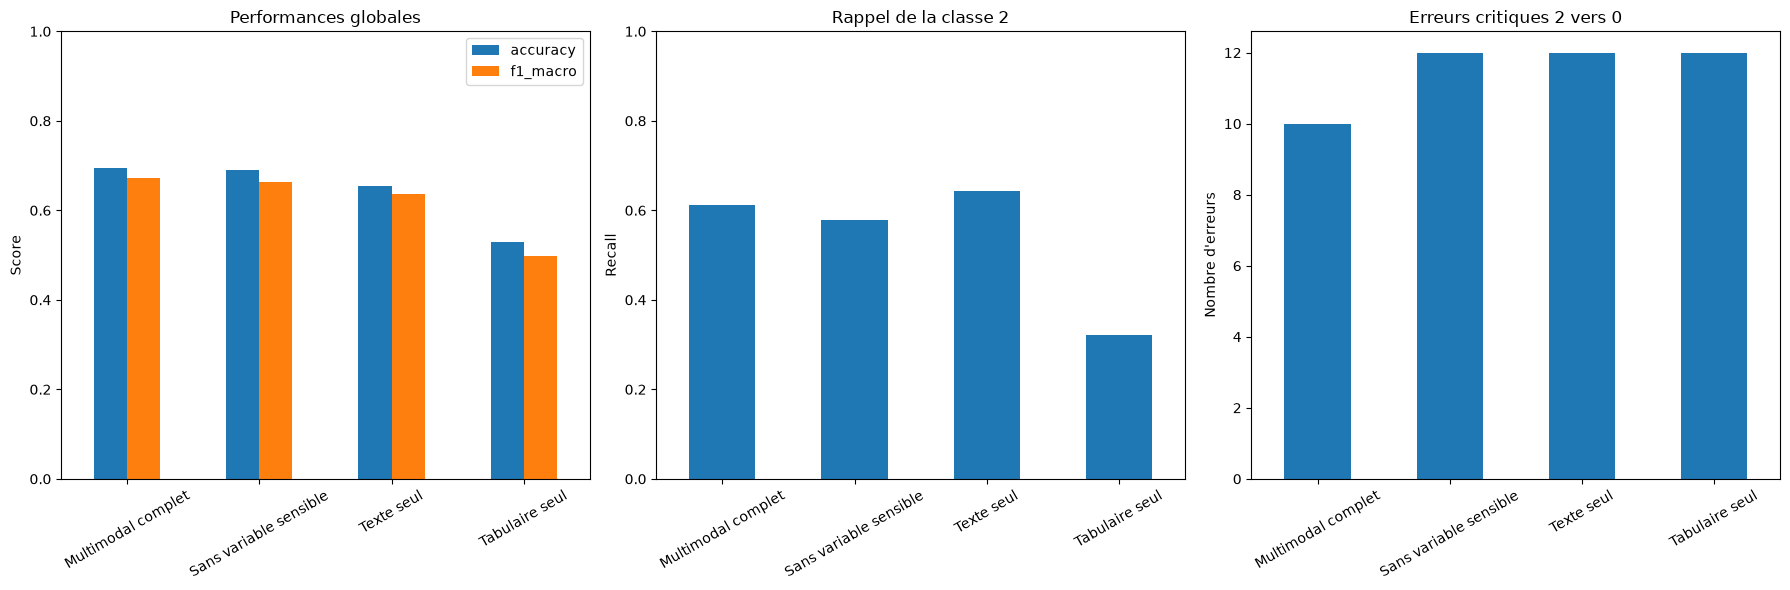

In [73]:
import matplotlib.pyplot as plt

# Copie pour conserver le tableau initial
df_visu = df_resultats_scenarios.copy()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

# Graphique 1 : performances globales
df_visu.plot(
    x="scenario",
    y=["accuracy", "f1_macro"],
    kind="bar",
    ax=axes[0]
)

axes[0].set_title(
    "Performances globales"
)

axes[0].set_xlabel("")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=30)


# Graphique 2 : rappel de la classe 2
df_visu.plot(
    x="scenario",
    y="recall_classe_2",
    kind="bar",
    legend=False,
    ax=axes[1]
)

axes[1].set_title(
    "Rappel de la classe 2"
)

axes[1].set_xlabel("")
axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=30)


# Graphique 3 : erreurs critiques
df_visu.plot(
    x="scenario",
    y="erreurs_critiques",
    kind="bar",
    legend=False,
    ax=axes[2]
)

axes[2].set_title(
    "Erreurs critiques 2 vers 0"
)

axes[2].set_xlabel("")
axes[2].set_ylabel("Nombre d'erreurs")
axes[2].tick_params(axis="x", rotation=30)


plt.tight_layout()
plt.show()

Scenario 3: Le texte seul détecte davantage d’individus de classe 2, mais il fait aussi davantage d’erreurs sur les autres classes. Cela signifie que le contenu de synthese_entretien porte une information importante pour repérer les situations à risque.

Scenario 4: Clairement le moins performant. Le tabulaire seul ne semble donc pas contenir suffisamment d’information pour répondre correctement au besoin. Cela confirme que le texte n’est pas un simple complément, mais une composante essentielle de la solution.

### CONCLUSION
Les quatre scénarios ont bien été évalués avec :
- le même découpage stratifié
- le même random_state
- le même modèle
- la même pondération des classes
- les mêmes indicateurs

La comparaison des quatre scénarios montre que l’approche multimodale complète (Scénario 1) obtient les meilleures performances globales, avec une accuracy de 0,694, un F1-score macro de 0,673 et 10 erreurs critiques.

Le retrait de la variable sensible 'nationalite_hors_ue' (Scénario 2) entraîne une dégradation limitée des performances, le F1-score macro passant de 0,673 à 0,664.

Le scénario texte seul (Scénario 3) conserve des résultats satisfaisants et obtient le meilleur rappel de la classe 2, à 0,644, ce qui confirme le fort pouvoir prédictif des synthèses d’entretien.

À l’inverse, le scénario tabulaire seul (Scenario 4) présente une forte baisse de performance, avec un F1-score macro de 0,497. Ces résultats démontrent que le texte constitue une composante essentielle de la solution.

Au regard du faible gain associé à la variable sensible et des risques de discrimination, le scénario multimodal sans variable sensible constitue un compromis pertinent entre performance, maîtrise du risque métier et principes d’IA responsable.

# -----------------------------------------------------------------------------------

# Chapitre 10 : Éthique, RGPD et Intelligence Artificielle Responsable

## 10.1 Enjeux éthiques du projet

L'objectif du projet est de prédire la classe de retour à l'emploi d'un demandeur d'emploi à partir de données sociodémographiques, professionnelles et textuelles issues des synthèses d'entretien.

Ce type de système peut avoir un impact direct sur l'orientation et l'accompagnement des bénéficiaires. Les décisions prises à partir des prédictions du modèle peuvent influencer l'accès à certaines mesures d'accompagnement ou à des dispositifs renforcés. Il est donc nécessaire d'intégrer des principes d'éthique et d'IA responsable tout au long du cycle de vie du projet.

Trois enjeux principaux ont été identifiés :

1. le risque de discrimination lié à l'utilisation de variables sensibles ;
2. le risque d'erreur de classification pour les publics les plus fragiles ;
3. la transparence et l'explicabilité du modèle.

## 10.2 Analyse des variables sensibles

La variable 'nationalite_hors_ue' peut être considérée comme sensible car elle est susceptible d'introduire des différences de traitement entre individus.

Afin d'évaluer son impact réel sur les performances du modèle, deux scénarios ont été comparés :
- scénario multimodal complet ;
- scénario multimodal sans la variable sensible.

Les résultats montrent que la suppression de la variable sensible entraîne une baisse limitée des performances. Le modèle reste donc performant sans utiliser cette information.

Conclusion : La variable sensible apporte une information prédictive complémentaire mais non indispensable.

## 10.3 Risque de variables proxy

L'analyse des coefficients du modèle a montré que certaines variables géographiques, notamment le département de résidence, figurent parmi les variables les plus influentes dans la prédiction.

Or certaines variables peuvent agir comme des variables proxy, c'est-à-dire des variables indirectement corrélées à des caractéristiques sensibles.

Même en supprimant la variable 'nationalite_hors_ue', une vigilance particulière demeure nécessaire concernant :
- le département
- certaines familles professionnelles
- d'éventuelles corrélations entre caractéristiques territoriales et situations sociales

## 10.4 Prise en compte du risque métier

L'erreur la plus critique est celle d'un demandeur d'emploi présentant un risque élevé de retour à l'emploi à long terme mais identifié à tort comme un profil revenant rapidement à l'emploi. Les conséquences potentielles sont :
- sous-estimation du besoin d'accompagnement
- absence de mobilisation de dispositifs renforcés
- risque accru de maintien dans le chômage de longue durée

Pour réduire ce risque, une pondération spécifique de la classe 2 a été introduite dans le modèle.
On peut dire que les conséquences métier des erreurs de prédiction dans le processus de modélisation ont bien été étudiées.

## 10.5 Transparence et explicabilité

L'étude des variables les plus influentes a montré que :
- les informations textuelles issues des synthèses d'entretien apportent une forte valeur prédictive
- certaines caractéristiques territoriales (département) jouent un rôle important
- certaines caractéristiques relatives à la qualification ou à la famille professionnelle contribuent également à la classification

Ces informations améliorent la compréhension du comportement du modèle et la capacité à détecter d'éventuels biais.

## 10.6 Conformité RGPD

Du point de vue du RGPD, plusieurs principes ont été pris en compte :

- Minimisation des données : Une évaluation spécifique de la variable sensible a été réalisée afin de déterminer si son utilisation était  nécessaire.

- Transparence : Les variables utilisées et leur impact ont été analysés.

- Limitation des risques : l'erreurs la plus préjudiciable a été identifiée puis spécifiquement réduite grâce à une pondération des classes.

- Gouvernance : Le modèle doit être considéré comme un outil d'aide à la décision et non comme un mécanisme de décision automatisée autonome. Les prédictions doivent être interprétées et intégrées dans un processus de décision humain.

# -----------------------------------------------------------------------------------

# Chapitre 11 : Industrialisation, déploiement et MLOps

## 11.1 Objectif

Nous avons construit un modèle de machine learning performant pour prédire la classe de retour à l’emploi à partir de données tabulaires et textuelles. L'étape suivante consiste à préparer son intégration dans un environnement de production afin qu'il puisse être utilisé de manière fiable, sécurisée et reproductible.

L'objectif est de mettre à disposition un service exploitable par les conseillers ou les applications métiers tout en garantissant la traçabilité des expériences et la maintenabilité de la solution.

## 11.2 Architecture cible

                 Utilisateur

                        ▼

                  API FastAPI

                        ▼

           Pipeline de prétraitement

                        ▼

               Modèle LinearSVC

                        ▼

                  Prédiction

                        ▼

                 Réponse JSON

Cette architecture permet de séparer :
- les données d'entrée
- les transformations
- le modèle
- l'exposition de la prédiction

## 11.3 Sauvegarde du modèle retenu

### 11.3.1 Création du dossier 'models'

In [74]:
from pathlib import Path

Path("../models").mkdir(
    parents=True,
    exist_ok=True
)

### 11.3.2 Entraînement du modèle sur l'ensemble du jeu d'entraînement

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

from src.preprocessing import (
    construire_preprocesseur,
    VARIABLES_NUMERIQUES,
    VARIABLES_CATEGORIELLES_SANS_SENSIBLE,
    VARIABLE_TEXTE
)

# Modèle final retenu
modele_final = Pipeline(
    steps=[
        (
            "preprocessing",
            construire_preprocesseur(
                variables_numeriques=VARIABLES_NUMERIQUES,
                variables_categorielles=VARIABLES_CATEGORIELLES_SANS_SENSIBLE,
                variable_texte=VARIABLE_TEXTE
            )
        ),
        (
            "modele",
            LinearSVC(
                C=0.1,
                class_weight={
                    0: 1,
                    1: 1,
                    2: 2
                },
                random_state=42
            )
        )
    ]
)

modele_final.fit(
    X_s2_train,
    y_s2_train
)

print("Modèle final entraîné.")

Modèle final entraîné.


### 11.3.3 Sauvegarde du pipeline complet

In [76]:
import joblib

joblib.dump(
    modele_final,
    "../models/modele_retour_emploi.joblib"
)

print(
    "Modèle sauvegardé avec succès."
)

Modèle sauvegardé avec succès.


### 11.3.4 Vérification que le modèle peut être rechargé

In [77]:
import joblib

modele_charge = joblib.load(
    "../models/modele_retour_emploi.joblib"
)

print(type(modele_charge))

<class 'sklearn.pipeline.Pipeline'>


### 11.3.5 Exemple d'utilisation du modèle sauvegardé

In [78]:
# Observation test
observation = X_test.iloc[[0]]

# Prédiction
prediction = modele_charge.predict(
    observation
)

print("Classe prédite :", prediction[0])

# Classe réelle
print(
    "Classe réelle :",
    y_test.loc[observation.index[0]]
)


Classe prédite : 1
Classe réelle : 1


Ce test permet de vérifier que le pipeline fonctionne bien sur un exemple donné.

In [79]:
from sklearn.metrics import (
    accuracy_score,
    f1_score
)

y_pred = modele_charge.predict(
    X_test
)

print(
    "Accuracy :",
    round(
        accuracy_score(
            y_test,
            y_pred
        ),
        3
    )
)

print(
    "F1 Macro :",
    round(
        f1_score(
            y_test,
            y_pred,
            average="macro"
        ),
        3
    )
)

Accuracy : 0.69
F1 Macro : 0.664


Le modèle a été sauvegardé puis rechargé. Les métriques obtenues après rechargement sont identiques à celles obtenues pendant l'entraînement, ce qui garantit la reproductibilité de la solution.

## 11.4 Mise en place de MLFlow

Après comparaison des différents scénarios et modèles, le pipeline final est réentraîné et suivi avec MLflow.
 
MLflow permet d'enregistrer les paramètres du modèle, les principales métriques d'évaluation et le pipeline entraîné. Cette traçabilité facilite
la comparaison des expériences et la reproductibilité du modèle retenu.

#### Imports et configuration

In [83]:
import mlflow
import mlflow.sklearn

from pathlib import Path

In [84]:
mlflow.set_experiment(
    "classification_retour_emploi"
)

2026/10/03 16:37:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/03 16:37:07 INFO mlflow.store.db.utils: Updating database tables
2026/10/03 16:37:09 INFO mlflow.tracking.fluent: Experiment with name 'classification_retour_emploi' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///C:/Users/a805339/Documents/FormationSimplon/UseCaseFinal/notebooks/mlruns/1', creation_time=1791038229322, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1791038229322, lifecycle_stage='active', name='classification_retour_emploi', tags={}, trace_location=None, workspace='default'>

#### Rappel du modèle sélectionné

In [86]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocesseur_final = construire_preprocesseur()

pipeline_final = Pipeline(
    steps=[
        (
            "preprocessing",
            construire_preprocesseur(
                variables_numeriques=VARIABLES_NUMERIQUES,
                variables_categorielles=VARIABLES_CATEGORIELLES_SANS_SENSIBLE,
                variable_texte=VARIABLE_TEXTE
            )
        ),
        (
            "modele",
            LinearSVC(
                C=0.1,
                class_weight={
                    0: 1,
                    1: 1,
                    2: 2
                },
                random_state=42
            )
        )
    ]
)


#### Entraînement final avec MLflow

In [88]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    confusion_matrix
)

with mlflow.start_run(
    run_name="modele_final_logistic_regression"
):

    # Entraînement
    pipeline_final.fit(
        X_train,
        y_train
    )

    # Prédictions
    y_pred_final = pipeline_final.predict(
        X_test
    )

    # Métriques
    accuracy_finale = accuracy_score(
        y_test,
        y_pred_final
    )

    f1_macro_final = f1_score(
        y_test,
        y_pred_final,
        average="macro"
    )

    rappel_classe_2 = recall_score(
        y_test,
        y_pred_final,
        labels=[2],
        average=None
    )[0]

    erreurs_critiques = (
        (y_test == 2) &
        (y_pred_final == 0)
    ).sum()

    # Paramètres MLflow
    mlflow.log_param(
        "modele",
        "LogisticRegression"
    )

    mlflow.log_param(
        "max_iter",
        1000
    )

    mlflow.log_param(
        "class_weight",
        "balanced"
    )

    mlflow.log_param(
        "scenario",
        "multimodal_complet"
    )

    # Métriques MLflow
    mlflow.log_metric(
        "accuracy",
        accuracy_finale
    )

    mlflow.log_metric(
        "f1_macro",
        f1_macro_final
    )

    mlflow.log_metric(
        "rappel_classe_2",
        rappel_classe_2
    )

    mlflow.log_metric(
        "erreurs_critiques_2_vers_0",
        int(erreurs_critiques)
    )

    # Sauvegarde du pipeline dans MLflow
    #mlflow.sklearn.log_model(
    #    pipeline_final,
    #    name="modele"
    #)

#### Résultats

In [89]:
print(
    "Accuracy :",
    round(accuracy_finale, 3)
)

print(
    "F1-score macro :",
    round(f1_macro_final, 3)
)

print(
    "Rappel classe 2 :",
    round(rappel_classe_2, 3)
)

print(
    "Erreurs critiques 2 vers 0 :",
    erreurs_critiques
)

Accuracy : 0.69
F1-score macro : 0.664
Rappel classe 2 : 0.578
Erreurs critiques 2 vers 0 : 12


#### Matrice de confusion finale

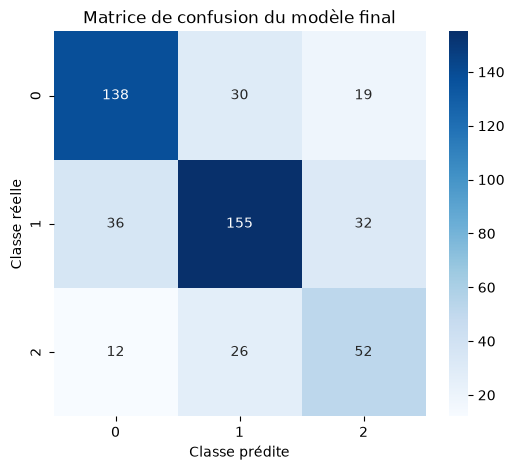

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

matrice_finale = confusion_matrix(
    y_test,
    y_pred_final
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matrice_finale,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Matrice de confusion du modèle final"
)

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")

plt.show()

#### Sauvegarde du modèle suivi

In [91]:
import joblib

DOSSIER_MODELES = Path("../models")

DOSSIER_MODELES.mkdir(
    exist_ok=True
)

CHEMIN_MODELE = (
    DOSSIER_MODELES
    / "modele_retour_emploi.joblib"
)

joblib.dump(
    pipeline_final,
    CHEMIN_MODELE
)

print(
    "Modèle sauvegardé :",
    CHEMIN_MODELE
)

print(
    "Fichier présent :",
    CHEMIN_MODELE.exists()
)

Modèle sauvegardé : ..\models\modele_retour_emploi.joblib
Fichier présent : True


### CONCLUSION
L'expérience finale a été enregistrée dans MLflow avec les paramètres dumodèle, l'accuracy, le F1-score macro, le rappel de la classe 2 et le nombre
d'erreurs critiques de type classe réelle 2 prédite en classe 0.

Le pipeline complet, incluant le prétraitement et le modèle, a ensuite été sauvegardé au format Joblib.

## 11.5 Création d'une API FastAPI

Le code de l'API est présent dans lke fichier main.py

Il contient une fonction /POST 'predict' qui prend en entrée les variables d'un enregistrement et retourne en sortie la classe prédite par le modèle.

### Tests manuels de l'API sur SWAGGER (http://127.0.0.1:8000/docs) :

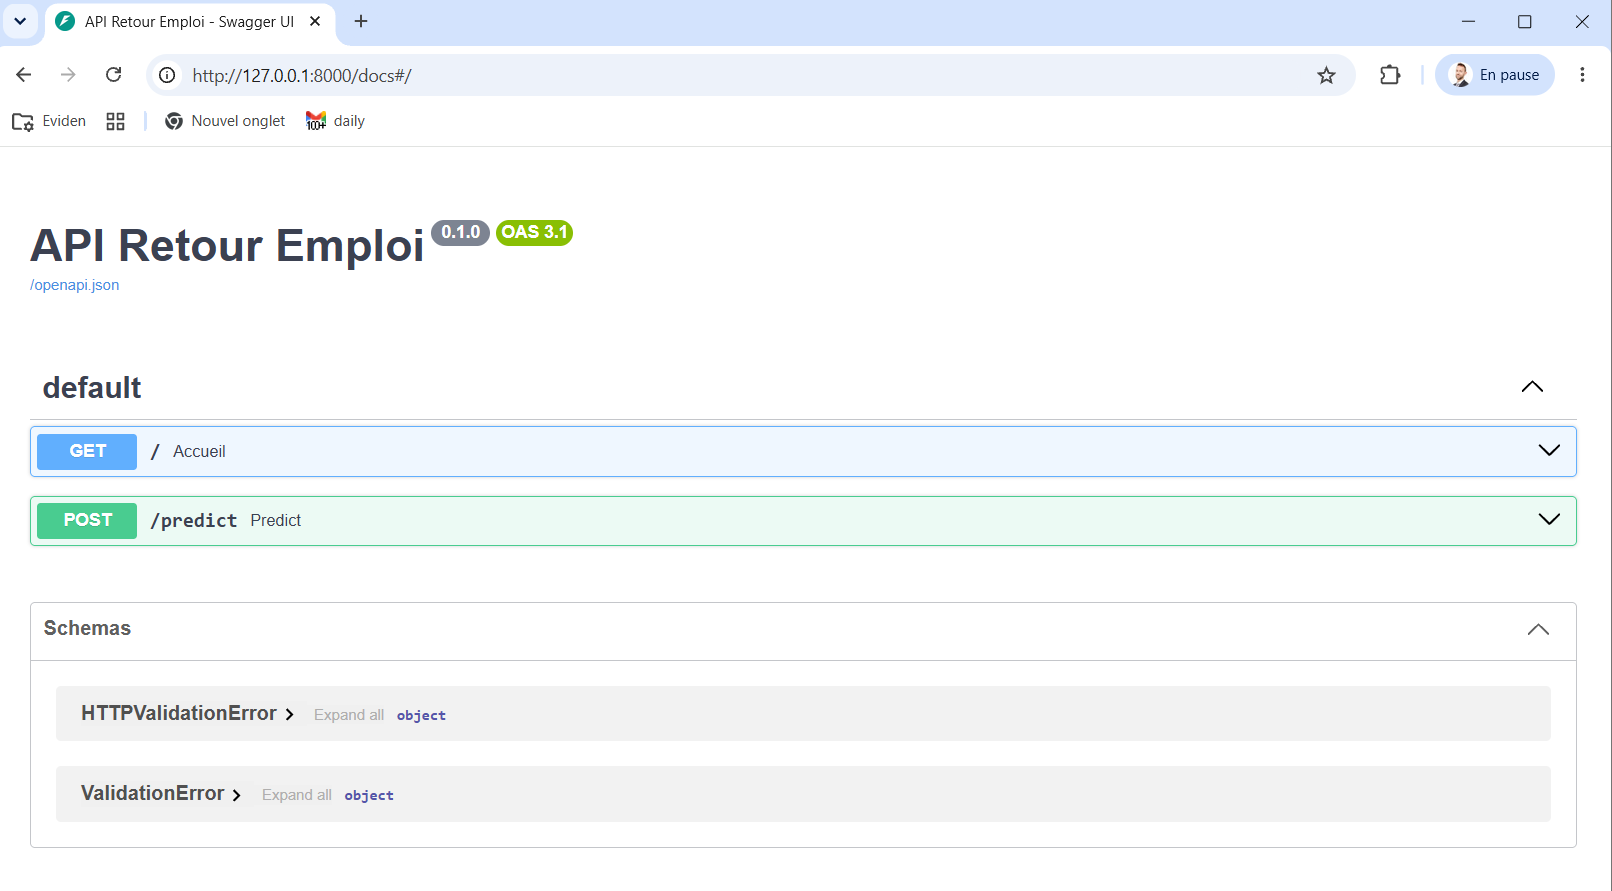

##### - Test GET (health) pour valider la disponibilté de l'API : positif

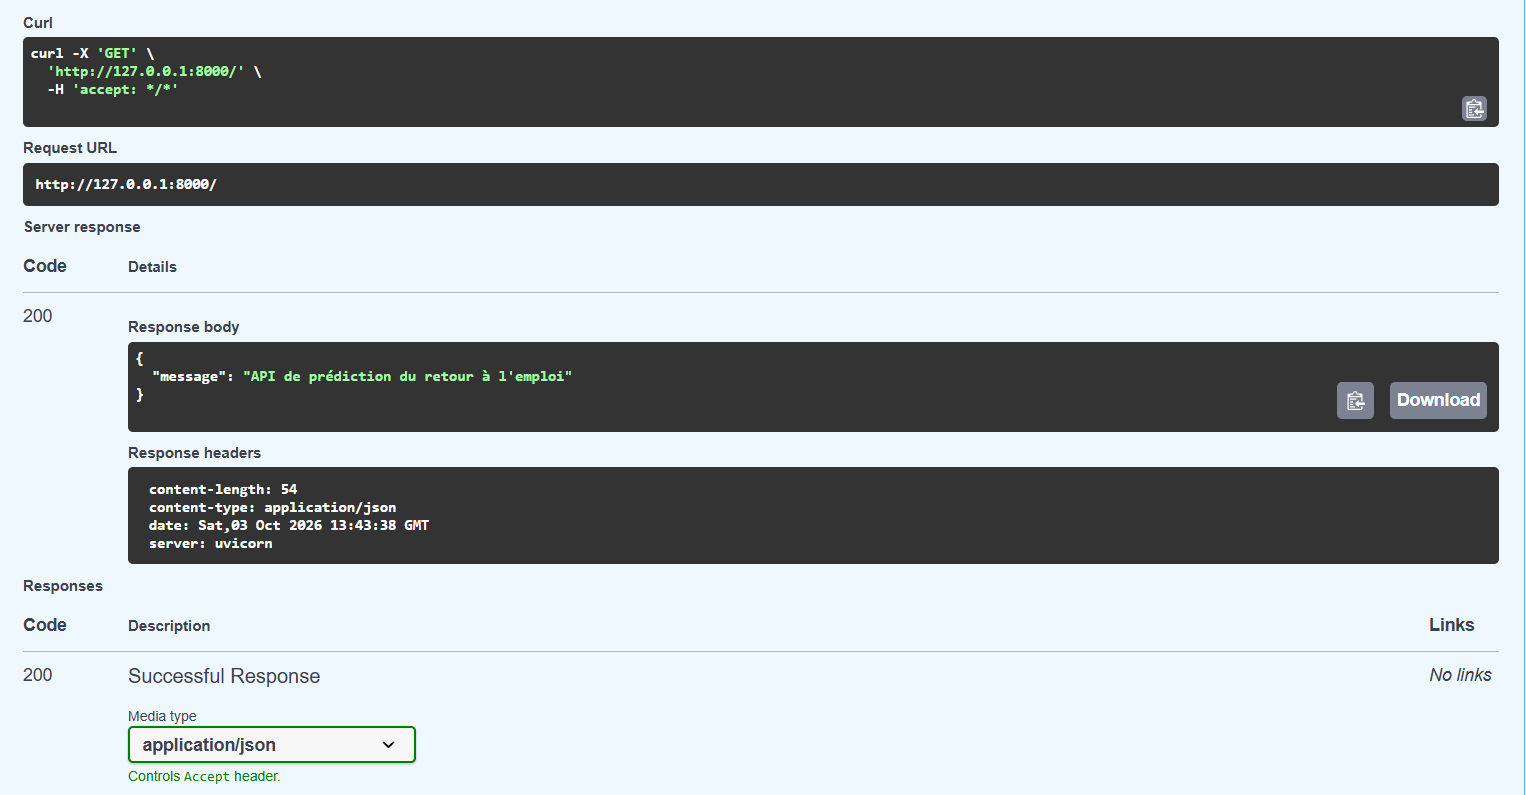

Tests POST /predict pour valider la disponibilité de l'API opérationnelle :
- 1er cas de test plutôt favorable à un retour à l'emploi > classe 0 / positif
- 2e cas de test plutôt fragile > classe 2 / positif

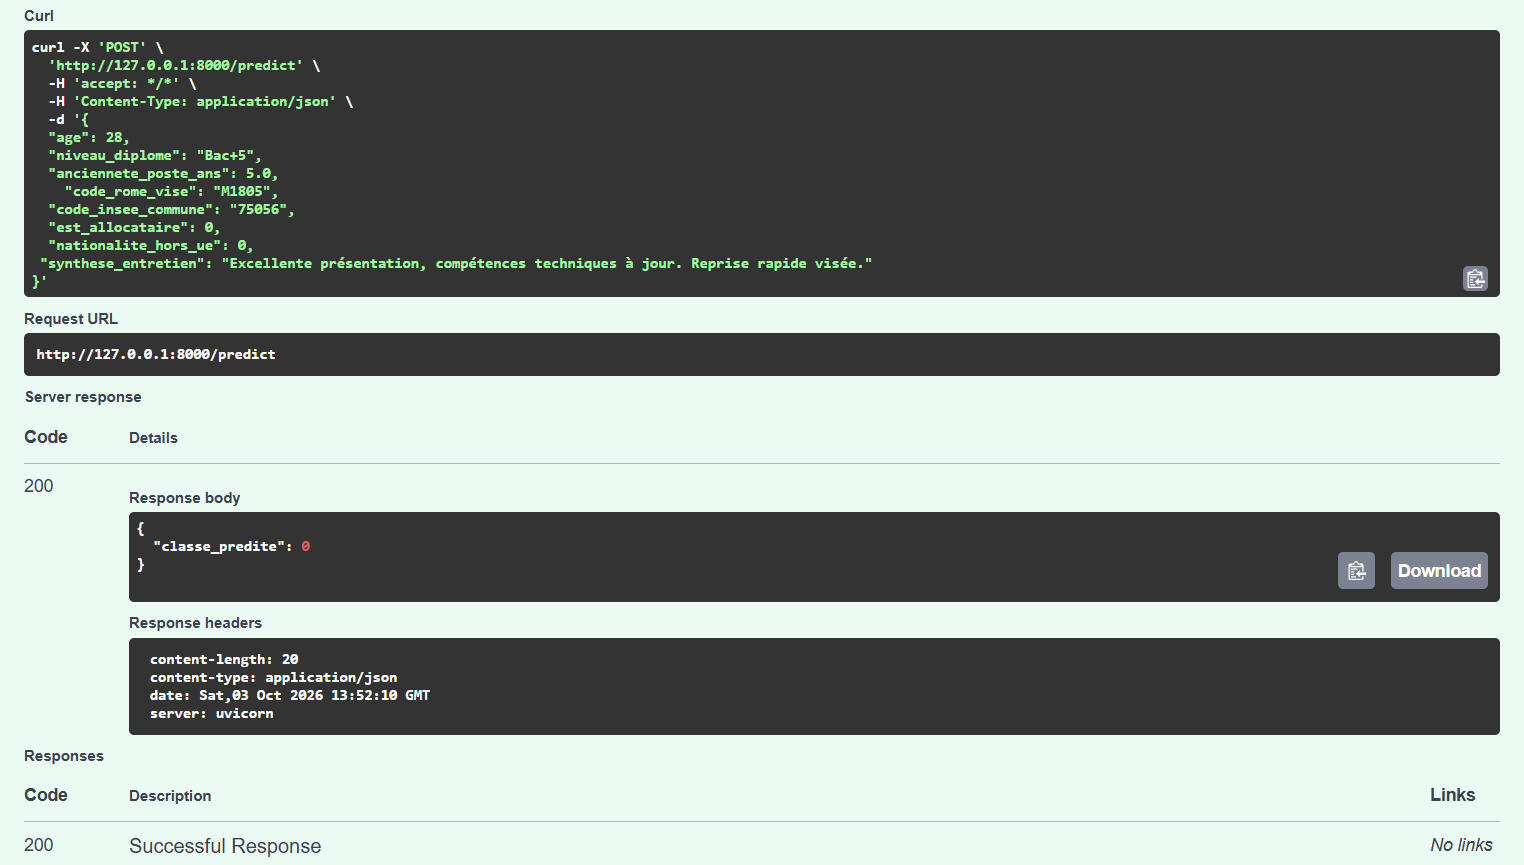

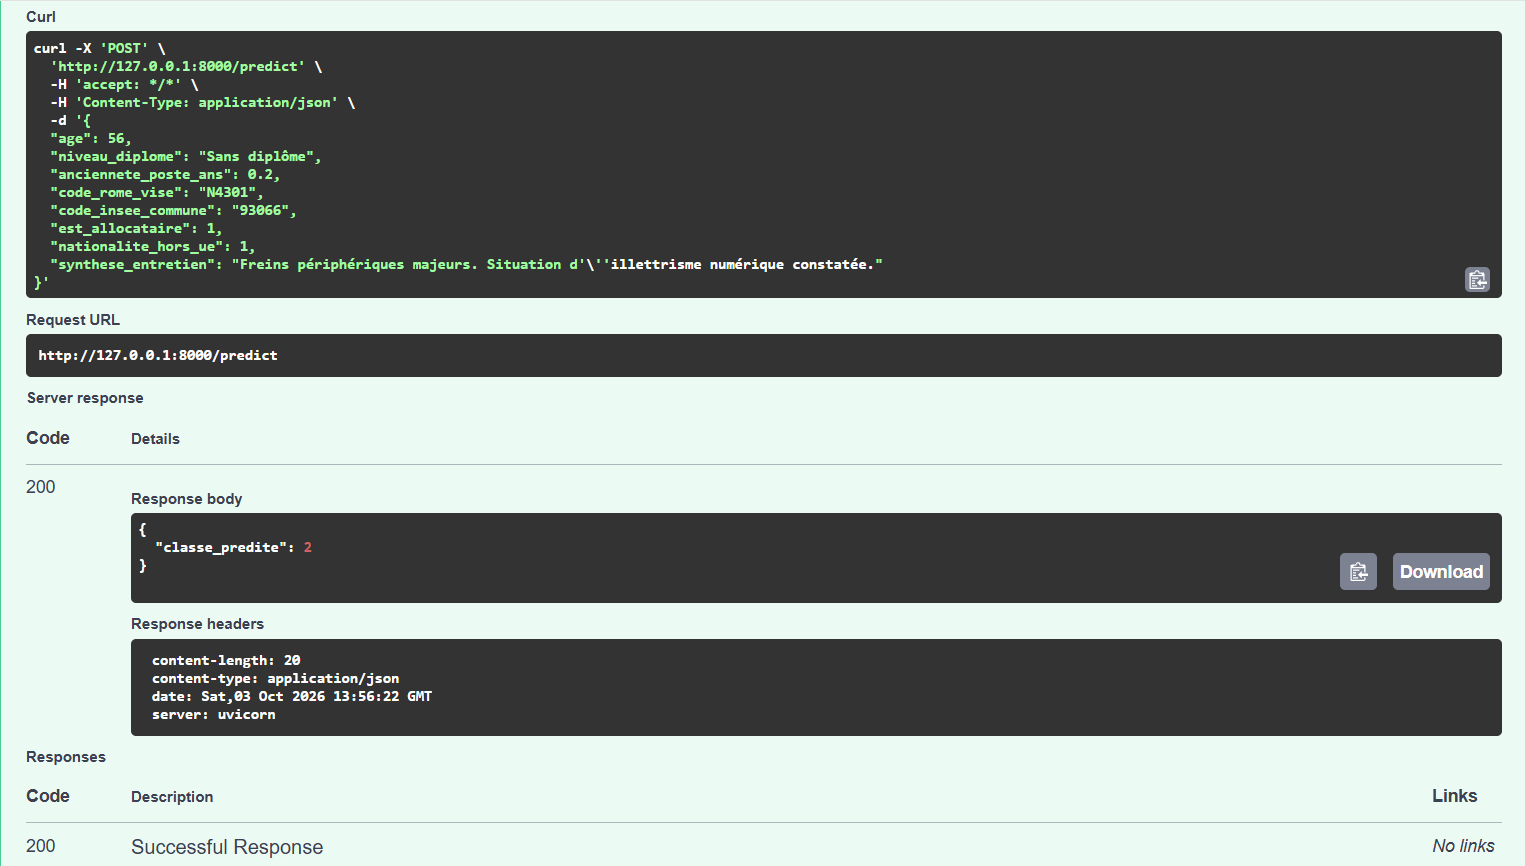

### Mise en place de tests automatiques de l'API dans le fichier tests/test_api.py
Objectif : valider le bon fonctionnement de l'API REST avant son intégration dans la chaîne CI/CD.
3 cas de tests ont été mis en place :
1. test GET /health
2. test POST /predict - classe 0 attendue
3. test POST /predict - classe 2 attendue 

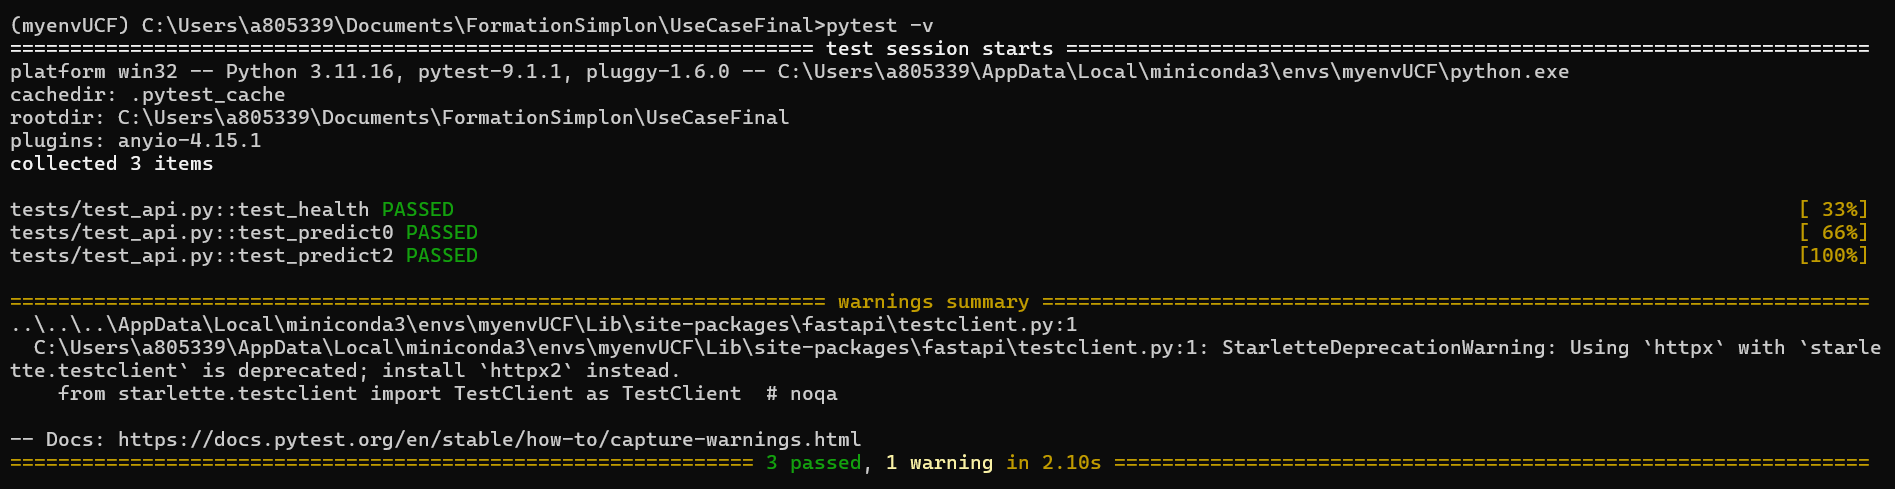

## 11.6 Containerisation avec Docker

Objectif : Garantir la reproductibilité du déploiement et embarquer l'ensemble des dépendances de l'application dans un environnement isolé.

Dockerfile : 

FROM python:3.11

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 8000

CMD ["python", "-m", "uvicorn", "api.main:app", "--host", "0.0.0.0", "--port", "8000"]


Commande de construction : docker build -t usecasefinal .

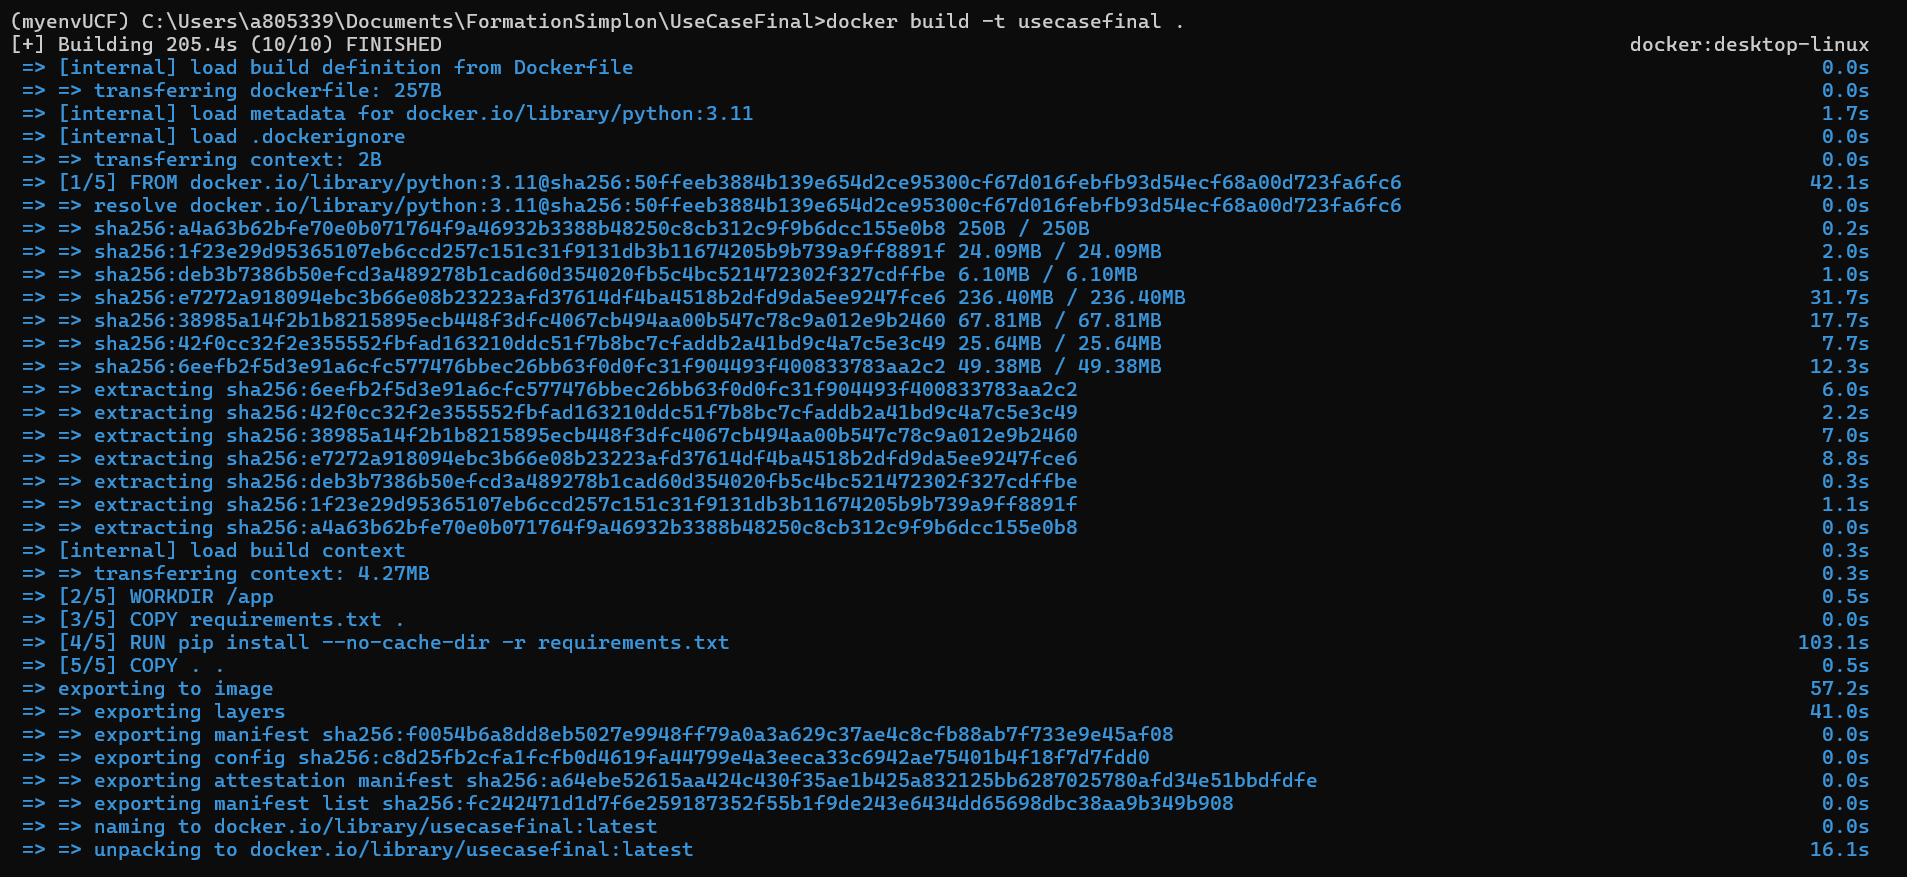

Commande d'exécution : docker run -p 8000:8000 usecasefinal

Commande d'exécution : docker run -p 8000:8000 usecasefinal

Résultat : L'application FastAPI est accessible via Swagger à l'adresse /docs depuis le conteneur Docker.

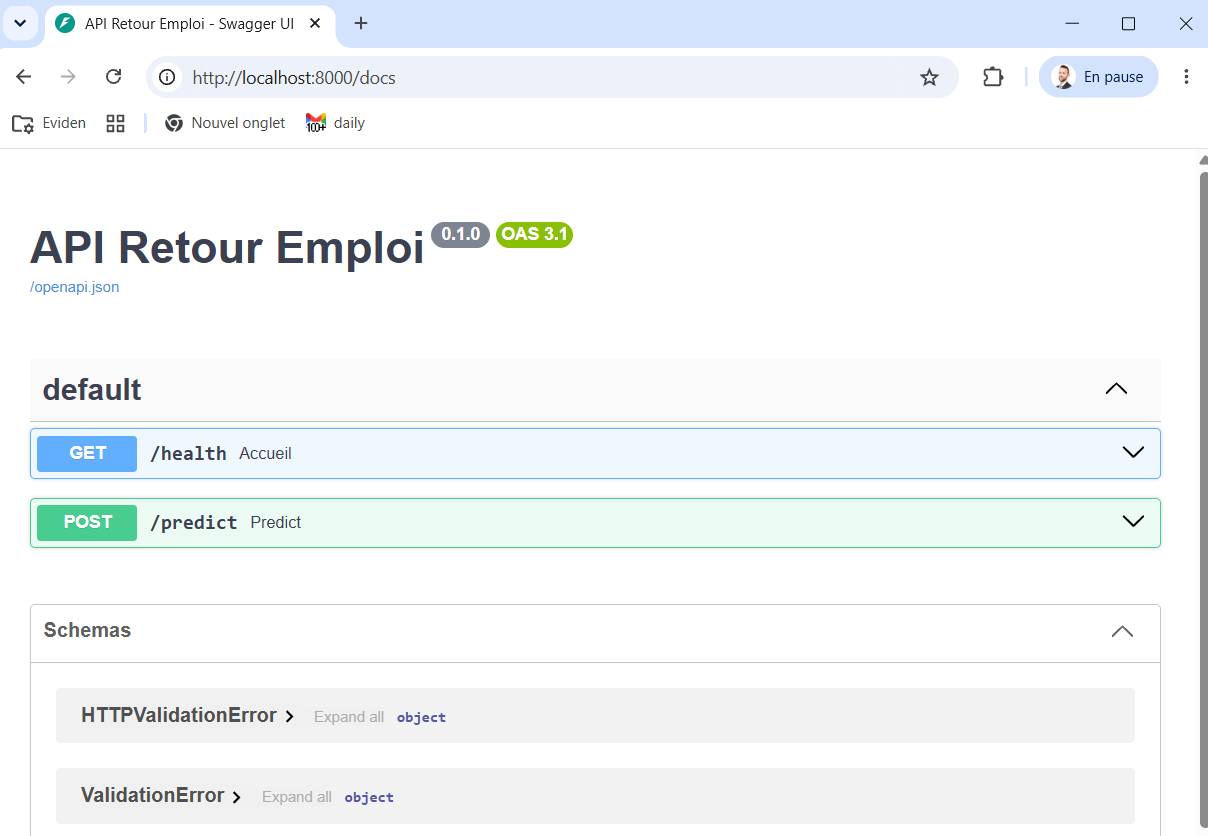